# Etapa 1 - Seleção do Escopo do problema

## Imports
* Imports das bibliotecas usadas durante o código.
* Import da Base de Dados - PNS 2019
----

In [1]:
from builtins import print
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display
from load import Atributos_Categoricos, Atributos_Numericos,filtrar_e_dropar_coluna
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [2]:
df = pd.read_csv(r'../Arquivos Csv\Base Completa\pns2019.csv')

df.shape

(293726, 1087)

## Definição do Escopo
O escopo tem 3 regras de delimitação:
   * Verficar se o registro teve a entrevista realizada, verficado pela variavel `V0015`:
   ``` python
   df = df[df['V0015'] == 1]
   ```
   * Delimitar a idade para 30 e 60, verificado pela `C008`:
   ``` python
   df = df[df['C008'].beetwen(30,59)]
   ```
   * Selecionar apenas as pessoas que responderam se foram **diagnosticadas ou não** com Asma, verificado pela variavel `Q074`:
   ``` python
   df = df[(df['Q074']==1) | (df['Q074']==2)]
   ```
----

In [3]:
# Tipo de entrevista - apenas Realizada == 01
# apenas entre 30 e 60 anos
# Apenas quem respondeu Q074 - se possui asma ou não

df = df[df['V0015'] == 1]

print(df['V0015'].value_counts())

df = df[df['C008'].between(30, 60)]

print(df['C008'].value_counts(ascending=True))

print(df.shape)

df = df[((df['Q074'] == 1) | (df['Q074'] == 2))]

print(df['Q074'].value_counts())

cols = ["Q00201","Q03001","Q060","Q06306","Q068","Q079","Q088","Q092","Q11006","Q11604","Q120","Q128","Q124","Q084"]

df_asmaticos = df[df['Q074'] == 1]
df_saudaveis_raw = df[df['Q074'] == 2]

# Refinar saudáveis (apenas quem respondeu 2 para todas as colunas da lista 'cols')
mask_sem_outras_doencas = (df_saudaveis_raw[cols] == 2).all(axis=1)
df_saudaveis_final = df_saudaveis_raw[mask_sem_outras_doencas]

# Unir os grupos novamente
df_final = pd.concat([df_asmaticos, df_saudaveis_final])

print(f"Asmáticos: {df_asmaticos.shape[0]}")
print(f"Saudáveis: {df_saudaveis_final.shape[0]}")

V0015
1    279382
Name: count, dtype: int64
C008
60.0    2878
58.0    3067
57.0    3091
59.0    3093
56.0    3340
54.0    3486
53.0    3490
47.0    3495
51.0    3499
52.0    3587
55.0    3592
50.0    3625
48.0    3721
49.0    3726
46.0    3777
45.0    3811
44.0    3859
41.0    3905
43.0    3921
31.0    4029
42.0    4036
32.0    4065
33.0    4086
34.0    4088
30.0    4153
35.0    4155
38.0    4244
39.0    4264
40.0    4287
36.0    4329
37.0    4460
Name: count, dtype: int64
(117159, 1087)
Q074
2.0    49380
1.0     2450
Name: count, dtype: int64
Asmáticos: 2450
Saudáveis: 19954


In [4]:
df_final.to_csv('../Arquivos Csv/Etapa1.csv')

### N° de registros após delimitação do Escopo

* Apenas entrevistas realizadas: **279382 registros**.
* Apenas entrevistas realizadas, entre 30 - 60 anos e responderam se possuem asma ou não: **22.404 registros**.
----

# Etapa 2/3 -Sseleção Conceitual de Atributos

## Rodar Etapa 2

In [5]:
df = pd.read_csv('../Arquivos Csv/Etapa1.csv')

print(df.shape)

(22404, 1088)


## Seleção dos Atributos do Modelo Conceitual
* Foram selecianados apenas as colunas que eram de interesse do modelo.
* Todas as colunas estão no arquivo `load.py`, separadas por categóricas e numéricas, além de uma breve descrição de seu respctivo significado.
* Antes: 1087 Colunas.
* Depois: 115 Colunas.
----

In [6]:
Atributos = Atributos_Categoricos + Atributos_Numericos

df = df[Atributos]

display(df.head())

print(df.shape)

df_copy = df.copy()

df_copy.to_csv(r'../Arquivos Csv/Etapa2_3.csv')

,A001,A002010,A005010,A005012,A009010,A01001,A011,A01403,A01501,A016010,...,P02002,P023,P02501,P02602,P02801,P035,P03904,P04001,VDF004,C001
0,2.0,1.0,2.0,1.0,5.0,7.0,1.0,NaN,2.0,1.0,...,0.0,0.0,0.0,1.0,NaN,3.0,5.0,NaN,7.0,2.0
1,1.0,1.0,3.0,1.0,1.0,6.0,2.0,NaN,3.0,1.0,...,0.0,7.0,3.0,0.0,NaN,NaN,NaN,NaN,4.0,2.0
2,2.0,1.0,1.0,NaN,6.0,2.0,1.0,NaN,4.0,1.0,...,0.0,4.0,2.0,0.0,NaN,NaN,NaN,NaN,1.0,4.0
3,1.0,1.0,1.0,NaN,5.0,5.0,2.0,NaN,4.0,1.0,...,0.0,0.0,0.0,0.0,NaN,3.0,NaN,NaN,4.0,3.0
4,1.0,1.0,1.0,NaN,5.0,2.0,1.0,NaN,4.0,1.0,...,0.0,7.0,0.0,0.0,1.0,NaN,5.0,NaN,5.0,1.0


(22404, 85)


# Etapa 4 - Análise de Outliers

## Rodar Etapa 4

In [7]:
df = pd.read_csv(r'../Arquivos Csv/Etapa2_3.csv')

## Remoção de Variáveis com altos Valores nulos
* Foram selecionados todas as colunas selecionadas no modelo com mais de 80% de dados vazios.
* Em cima dessas colunas foi feito uma analise conceitual, visando analisar o contexto para os dados vazios da coluna e sua importancia do para o modelo.
* Em algumas das colunas foi verificada que apenas **uma porção dos 22.404 registros** deviam responder ela, derivada de uma resposta de outra pergunta, para essas variaveis foi feito uma analise em cima desse **novo valor máximo** ( o numero de respostas da outra pergunta) em comparação ao numero de registros que responderam de fato, caso fosse abaixo de 80% seria mantida, caso contrário, seria deletada.
* Após essa seleção o numero de atributos desceu de **108 para 103**.
* Foram eliminado os seguintes atributos: `[]`.
----

In [8]:
df.drop(inplace=True,columns=['L01701','J01802','J023','J024','A005012'])

df.shape

(22404, 81)

## Remoção de Registros de Atributos com Valores Constantes

* Foi feito uma análise para encontrar atributos categóricos com um valor predominante (Acima de 75% das respostas).
* Uma vez identificado foi feita uma remoção dos registros que compunham as outras respostas ( fora dos 75% ou mais).
* Após deixar apenas os registros com as outras respostas, este atributo se torna uma constante, portanto, ele é eliminado.
* Foram eliminado os seguintes atributos: `['M001','A016010']`.
----

In [9]:
# Define o threshold (75%)
threshold = 0.75

# Lista para armazenar as variáveis que atendem o critério
variaveis_dominantes = []

# Analisa todas as colunas do DataFrame (ajuste 'df' para o nome do seu dataframe)
for col in df.columns:
    # value_counts(dropna=False) conta os nulos como uma categoria
    # normalize=True transforma a contagem em porcentagem (0 a 1)
    frequencias = df[col].value_counts(dropna=False, normalize=True)

    # Verifica se a maior frequência é >= 0.75
    if frequencias.iloc[0] >= threshold:
        valor_mais_frequente = frequencias.index[0]
        porcentagem = frequencias.iloc[0] * 100
        variaveis_dominantes.append((col, valor_mais_frequente, porcentagem))

# Exibe o resultado
print(f"{'Variável':<15} | {'Valor Dominante':<15} | {'Porcentagem':<10}")
print("-" * 45)
for var, valor, perc in variaveis_dominantes:
    print(f"{var:<15} | {str(valor):<15} | {perc:.2f}%")

Variável        | Valor Dominante | Porcentagem
---------------------------------------------
A001            | 1.0             | 86.29%
A002010         | 1.0             | 84.95%
A005010         | 1.0             | 78.09%
A01403          | nan             | 96.68%
A016010         | 1.0             | 81.36%
D001            | 1.0             | 93.91%
E022            | nan             | 77.91%
I00102          | 2.0             | 75.92%
M001            | 1.0             | 100.00%
N012            | 1.0             | 79.18%
N016            | 1.0             | 80.82%
N017            | 1.0             | 88.80%
N018            | 1.0             | 97.22%
P044            | 2.0             | 84.52%
P04401          | nan             | 84.52%
P050            | 3.0             | 87.91%
P051            | nan             | 98.75%
P068            | 5.0             | 87.63%
Q074            | 2.0             | 89.06%
R028            | nan             | 90.49%
R029            | nan             | 91.41%
VD

In [10]:
cols = ['M001','A016010','D001']

df = filtrar_e_dropar_coluna(df, cols)

## Remoção de Valores Desinformativos
* Valores desinformativos é considerados respostas que não trazem nenhuma informação relevante, como: 'não se aplica', 'não sei', etc.
---

In [11]:
def mapear_valores_especiais(df):
    # Lista com todas as variações possíveis (int, float e string) para evitar que algum passe despercebido
    valores_procurados = [
        9, 99, 999, 9999,
        9.0, 99.0, 999.0, 9999.0,
        '9', '99', '999', '9999'
    ]

    colunas_com_especiais = []

    for col in df.columns:
        # Pega apenas os registros da coluna que batem com nossa lista de valores
        ocorrencias = df[col][df[col].isin(valores_procurados)]

        # Se encontrou pelo menos um registro
        if not ocorrencias.empty:
            # Conta quantas vezes cada valor apareceu
            contagem = ocorrencias.value_counts().to_dict()

            # Formata o resultado para ficar fácil de ler
            detalhes = ", ".join([f"Valor {k}: {v} vezes" for k, v in contagem.items()])
            colunas_com_especiais.append({
                'Coluna': col,
                'Detalhes': detalhes
            })

    # Transforma em um DataFrame para visualização bonita no Jupyter
    df_resultado = pd.DataFrame(colunas_com_especiais)

    return df_resultado

# --- Como executar ---
resultado_9 = mapear_valores_especiais(df)
resultado_9

,Coluna,Detalhes
0,Unnamed: 0,"Valor 9: 1 vezes, Valor 99: 1 vezes, Valor 999..."
1,A01001,Valor 9.0: 626 vezes
2,C009,Valor 9.0: 1 vezes
3,R025,Valor 9.0: 162 vezes
4,VDE014,Valor 9.0: 2147 vezes
5,A02305,Valor 9.0: 14 vezes
6,A02306,Valor 9.0: 15 vezes
7,A02307,Valor 9.0: 7 vezes
8,P00104,Valor 99.0: 43 vezes
9,C001,Valor 9.0: 24 vezes


In [12]:
cols = ['C009']

df = df[(df['C009'] != 9)]

df.shape

(17537, 78)

In [13]:
df_copy = df.copy()

df_copy.to_csv(r'../Arquivos Csv/Etapa4.csv')

# Etapa 5 - Tratamento de Dados Ausentes e Vazios

## Rodar Etapa 5

In [14]:
df = pd.read_csv(r'../Arquivos Csv/Etapa4.csv')

## Dados Vazios

* Serão eliminados, todas os atributos são pouco relevantes e não há forma de imputação ou de discretização eficiente.

## Dados Ausentes - Imputação / discretização

* Para os atributos que possuem dados ausentes será implementado

In [15]:
print('Asmaticos:')
print(df[(df['Q074'] == 1)]['VDE014'].isna().sum())


print('Saudaveis:')
print(df[(df['Q074'] == 2)]['VDE014'].isna().sum())

print(df[(df['E001'] == 2) & (df['E002'] == 2) & (df['E003'] == 2)]['VDE014'].isna().sum())

print(df['VDE014'].isna().sum())


Asmaticos:
503
Saudaveis:
2999
3502
3502


* Todos os registros que responderam que não estao em um emprego remunerado em: `E001`, `E002`, `E003`. Estão como `NaN` em `VDE014`, portanto, será imputado valor 0, equivalente a desempregado.

In [16]:
mask_imputar = (
    (df['E001'] == 2) &
    (df['E002'] == 2) &
    (df['E003'] == 2) &
    (df['VDE014'].isna())
)

df.loc[mask_imputar, 'VDE014'] = 0

print(df['VDE014'].value_counts(dropna=False).sort_index())


VDE014
0.0     3502
1.0      602
2.0     1489
3.0     1031
4.0     2606
5.0      799
6.0      772
7.0     1678
8.0     1122
9.0     2147
10.0     730
11.0    1054
12.0       5
Name: count, dtype: int64


* Como as colunas `E001`, `E002`, `E003` representa as pessoas não remuneradas e são o resultado do valor 0 na variavel `VDE014`, elas serão removidas apos a transformação.

* será feito um agrupamento para reduzir o N° de categorias, esse agrupamento é baseado na natureza da ocupação.

In [17]:
# Legenda do novo agrupamento:
# 0 = Fora da Força de Trabalho (Não trabalha)
# 1 = Trabalho Rural / Extrativista (Agricultura, pecuária, etc.)
# 2 = Trabalho Operacional / Logístico (Indústria, construção, transporte)
# 3 = Comércio e Serviços Pessoais (Comércio, alimentação, outros serviços, serv. domésticos)
# 4 = Trabalho Administrativo / Técnico (Informação, financeiro, adm. pública, saúde, educação)
# 9 = Maldefinido (Atividades maldefinidas)

mapeamento_trabalho_numerico = {
    0.0: 0,
    1.0: 1,
    2.0: 2,
    3.0: 2,
    4.0: 3,
    5.0: 2,
    6.0: 3,
    7.0: 4,
    8.0: 4,
    9.0: 4,
    10.0: 3,
    11.0: 3,
    12.0: 9
}

# Criando a nova coluna mapeando diretamente os floats originais
df['Natureza_Trabalho'] = df['VDE014'].map(mapeamento_trabalho_numerico)

# Verificando o resultado para confirmar o agrupamento
print(df['Natureza_Trabalho'].value_counts(dropna=False).sort_index())

df.drop(inplace=True,columns=['VDE014'])

Natureza_Trabalho
0    3502
1     602
2    3319
3    5162
4    4947
9       5
Name: count, dtype: int64


In [18]:
pd.crosstab(df['Q074'],df['Natureza_Trabalho'])

Natureza_Trabalho,0,1,2,3,4,9
Q074,,,,,,
1.0,503,46,277,500,611,1
2.0,2999,556,3042,4662,4336,4


* IMC = Peso / Altura^2


In [19]:
print(df['P00104'].isna().sum())

print(df['P00404'].isna().sum())

df.dropna(subset=['P00104','P00404'],inplace=True)

# Cálculo do IMC
# Assumindo que P00404 (Altura) está em centímetros, dividimos por 100
df['IMC'] = df['P00104'] / ((df['P00404'] / 100) ** 2)

# Opcional: Remover possíveis NaNs gerados pelo cálculo (caso peso ou altura fossem nulos)
df = df.dropna(subset=['IMC'])

# Visualizando as primeiras linhas do cálculo
print(df[['P00104', 'P00404', 'IMC']].head())

bins = [0, 18.5, 25, 30, 35, 40, np.inf]
labels = [1, 2, 3, 4, 5, 6]

# Usamos right=False para que o valor exato (ex: 25.0) pule para a próxima categoria
df['IMC'] = pd.cut(df['IMC'], bins=bins, labels=labels, right=False).astype(int)

print(df['IMC'].value_counts().sort_index())

df.drop(columns=['P00104','P00404'],inplace=True)

152
152
   P00104  P00404        IMC
0    72.0   169.0  25.209201
1    78.0   165.0  28.650138
3    65.0   156.0  26.709402
4    88.0   163.0  33.121307
5    77.0   176.0  24.857955
IMC
1     223
2    6710
3    7011
4    2642
5     638
6     161
Name: count, dtype: int64


In [20]:
pd.crosstab(df['Q074'],df['IMC'])

IMC,1,2,3,4,5,6
Q074,,,,,,
1.0,21,612,735,386,127,40
2.0,202,6098,6276,2256,511,121


* Para a variavel `P039` e `P03904` será feito um Concatenação Lógica.

* A variavel `E011` se refer as pessoas ocupada (empregada), logo, quem não está ocupado não realiza atividades fisicas por conta do emprego.
* Portanto será imputado valor 0 nesses registros.
* Caso a resposta de `P038` e `P039` sejam 2, ou seja, Não, será imputado 0 na variavel `P03904`, pois a pessoa é empregada mas não realiza exercicio devido ao emprego.
* Para a variavel `P03904`, zero é igual a não realiza esforço por conta do trablho.
* Como todas as informações estão contidas (intensidade e se realiza ou não) na variavel `P03904`, as variaveis `P038` e `P039`, serão excluidas.

In [21]:
# 1. Imputar nulos de P038 como 0 (Não possui emprego/Não se aplica)
df['P038'] = df['P038'].fillna(0)

display(df['P038'].value_counts())

def consolidar_esforco(row):
    # Se ambos responderam 'Não' (2.0)
    if row['P038'] == 2 and row['P039'] == 2:
        return 0
    # Se o valor de P03904 for nulo, mas houve resposta 1 em P038 ou P039,
    # geralmente imputamos 0 ou mantemos NaN conforme a sua regra.
    # Aqui, garantimos que se o fluxo diz que não teve esforço, é 0.
    return row['P03904']

# Aplicando a lógica
df['P03904'] = df.apply(consolidar_esforco, axis=1)

# 3. Limpeza final: tratar nulos restantes em P03904 como 0
# (Ex: pessoas que não trabalham ou não passaram pelo filtro)
df['Exercício pesado trabalho'] = df['P03904'].fillna(0).astype(int)

# Verificação
print(df['Exercício pesado trabalho'].value_counts().sort_index())

df.drop(inplace=True, columns=['P038','P039','P03904'])

P038
2.0    8986
1.0    4945
0.0    3454
Name: count, dtype: int64

Exercício pesado trabalho
0    11400
1      438
2      541
3      773
4      429
5     2012
6     1384
7      408
Name: count, dtype: int64


* Será feito uma discretização em cima dos dias, sendo separado por 4 categorias, até 3 dias, até 5 dias e + 5 dias e 0 dias.

In [22]:
# 0 Não faz exercicio pesado no trabalho
# alguns dias de trabalho faz exercicio pesados
# faz exercicio pesado no trabalho durante todos os dias uteis
# Faz exercicio pesado no trabalho durante o fim de semana
remap = {
    0.0:0,
    1.0:1,
    2.0:1,
    3.0:2,
    4.0:2,
    5.0:2,
    6.0:3,
    7.0:3,
}

df['Exercício pesado trabalho'] = df['Exercício pesado trabalho'].map(remap)

print(df['Exercício pesado trabalho'].value_counts())

Exercício pesado trabalho
0    11400
2     3214
3     1792
1      979
Name: count, dtype: int64


In [23]:
pd.crosstab(df['Q074'],df['Exercício pesado trabalho'])

Exercício pesado trabalho,0,1,2,3
Q074,,,,
1.0,1256,131,354,180
2.0,10144,848,2860,1612


* A variável P050, P051 e P052, possuem a mesma lógica de salto, sendo a P050 a pergunta originária.
* Caso a resposta de P050 seja 2 essa pessoa é redirecionada para P051.
* Caso a resposta de P050 seja igual a 3 a pessoa é redirecionada para P052.
* As variáveis M01001 e P068 (em domicílio) informam se a pessoa se enquadra em fumantes passivos, esses registros dependem que a resposta da variável M009 seja 1 ou 3 (trabalho em ambientes fechados).
* A classificação de fumante passivo será aplicada apenas se o registro em questão não usar ou ter usado algum produto de tabaco.

---

* As variáveis dizem se a pessoa fuma atualmente (diariamente ou não), se já fumou no passado (diariamente ou não) ou se se enquadra em fumante passivo. Para otimizar o poder preditivo do modelo e agrupar comportamentos estatísticos e médicos semelhantes, elas serão agrupadas em uma variável categórica contendo 4 macro-perfis de risco.
* Serão as seguintes categorias:
    * Histórico de Parada [Causalidade Reversa - Ex-fumantes ou quem reduziu o uso] ((Resposta da P050 == 2 e Resposta da P051 == 1) ou (Resposta da P050 == 3 e Resposta da P052 == 1 ou 2))
    * Fumante Ativo Contínuo [Fumantes diários ou ocasionais contínuos] (Resposta da P050 == 1) ou (Resposta da P050 == 2 e Resposta da P051 == 2)
    * Fumante passivo (Resposta da P050 == 3 e Resposta da P052 == 3 e Resposta da M01001 == 1) ou (Resposta da P050 == 3 e Resposta da P052 == 3 e Resposta da P068 == 1 ou 2)
    * Não fumante [Baseline - Nunca fumou e não foi capturado nos filtros de exposição] (Resposta da P050 == 3 e Resposta da P052 == 3)

In [24]:
print(df.shape)

# 2. Definir as condições lógicas baseadas nos 4 Macro-Perfis de Risco
condicoes = [
    # 4 = Histórico de Parada (Causalidade Reversa: Ex-fumantes ou quem reduziu de diário para ocasional)
    ((df['P050'] == 2) & (df['P051'] == 1)) | ((df['P050'] == 3) & (df['P052'].isin([1, 2]))),

    # 3 = Fumante Ativo Contínuo (Fumante diário ou ocasional que sempre foi ocasional)
    (df['P050'] == 1) | ((df['P050'] == 2) & (df['P051'] == 2)),

    # 2 = Fumante passivo (Nunca fumou, mas foi exposto no trabalho ou domicílio)
    ((df['P050'] == 3) & (df['P052'] == 3) & (df['M01001'] == 1)) |
    ((df['P050'] == 3) & (df['P052'] == 3) & (df['P068'].between(1,2))),

    # 1 = Não fumante (Nunca fumou e não foi capturado na malha fina do fumante passivo acima)
    (df['P050'] == 3) & (df['P052'] == 3)
]

# Mapeamento de 'perfil_tabagismo':
# 4 = Histórico de Parada (Maior risco estatístico)
# 3 = Fumante Ativo Contínuo
# 2 = Fumante passivo
# 1 = Não fumante (Baseline)
# 0 = Nao Classificado / Dados Inconsistentes (Default)
categorias = [4, 3, 2, 1]

# 4. Criar a nova variável numérica no df
df['perfil_tabagismo'] = np.select(condicoes, categorias, default=0).astype(int)

df.drop(inplace=True, columns=['P050','P051','P052','M01001','M009','P068'])

# Visualizar o resultado para conferência dos códigos numéricos
print(df['perfil_tabagismo'].value_counts().sort_index())
print(f"Total classificados: {df['perfil_tabagismo'].value_counts().sum()}")
print(df.shape)

(17385, 76)
perfil_tabagismo
1    11065
2      963
3     1799
4     3558
Name: count, dtype: int64
Total classificados: 17385
(17385, 71)


In [25]:
pd.crosstab(df['Q074'],df['perfil_tabagismo'])

perfil_tabagismo,1,2,3,4
Q074,,,,
1.0,1048,122,218,533
2.0,10017,841,1581,3025


* A variável A005010 refere-se à forma principal de abastecimento de água do domicílio, sendo dividida em 6 categorias.

* A variável A005012 questionava se o domicílio estava ligado à rede geral de distribuição, caso a resposta da variável anterior indicasse outra fonte. (Nota: Esta variável foi descartada no tratamento de dados para evitar redundância e constância na modelagem).
---
* A informação de abastecimento foi consolidada em uma nova variável categórica binária, agrupando os níveis de acesso à água:

* Ligado à rede geral de distribuição (Resposta da A005010 == 1)

* Não ligado à rede geral de distribuição / Uso de fontes alternativas (Resposta da A005010 pertencente a [2, 3, 4, 5, 6])

In [26]:
import numpy as np

# Discretização Binária: Acesso à rede de água pública
condicoes = [
    # 1 = Possui acesso à rede geral de distribuição (Alta infraestrutura)
    (df['A005010'] == 1),

    # 0 = Depende de fontes alternativas ou precárias (Poços, nascentes, chuva, caminhão pipa)
    (df['A005010'].isin([2, 3, 4, 5, 6]))
]

categorias = [1, 0]

# Criando a nova variável binária
df['acesso_rede_agua'] = np.select(condicoes, categorias, default=0).astype(int)

# Verificando a distribuição
print(df['acesso_rede_agua'].value_counts(dropna=False))

# Removendo a coluna original
df.drop(columns=['A005010', 'A005012'], inplace=True, errors='ignore')

acesso_rede_agua
1    15344
0     2041
Name: count, dtype: int64


In [27]:
pd.crosstab(df['Q074'],df['acesso_rede_agua'])

acesso_rede_agua,0,1
Q074,,
1.0,200,1721
2.0,1841,13623


* As variáveis P044, P04401, P04405 e P04406 referem-se à realização de esforço físico intenso devido a atividades habituais (faxina doméstica pesada).

* A variável P044 atua como pergunta filtro (skip logic). Caso a resposta seja 2 (Não), a pessoa é dispensada das demais perguntas. A variável P04401 quantifica o número de dias na semana. As variáveis de tempo em horas e minutos (P04405 e P04406) foram descartadas da modelagem para eliminar ruídos de estimativa subjetiva.

* A informação de dias de faxina pesada foi consolidada em uma única variável categórica ordinal (Exercicio_domestico), padronizada com os mesmos "degraus" de intensidade utilizados para o esforço físico no trabalho, garantindo simetria para o algoritmo.

* Foi imputado o valor 0 (zero dias) para os registros que não realizam atividades domésticas pesadas (Resposta da P044 == 2) ou que possuíam dados nulos.
---
* A discretização seguiu as seguintes categorias baseadas na frequência semanal:

    * 0 = Nenhum (0 dias)

    * 1 = Esporádico (1 a 2 dias na semana)

    * 2 = Frequente (3 a 5 dias na semana)

    * 3 = Intenso (6 a 7 dias na semana)

In [28]:
print(df.shape)

# 1. Tratar os dias na semana (P04401).
# Se a pessoa respondeu 'Não' para faxina pesada (P044 == 2) ou se for nulo, consideramos 0 dias.
df['dias_faxina'] = np.where(df['P044'] == 2, 0, df['P04401'].fillna(0))

# 2. Aplicar exatamente o mesmo dicionário de cortes usado no exercício do trabalho
remap_dias = {
    0.0: 0, # Nenhum (0 dias)
    1.0: 1, # Esporádico (1 a 2 dias)
    2.0: 1,
    3.0: 2, # Frequente (3 a 5 dias)
    4.0: 2,
    5.0: 2,
    6.0: 3, # Intenso (6 a 7 dias)
    7.0: 3
}

# 3. Consolidar na variável final e tipar como inteiro
df['Exercicio_domestico'] = df['dias_faxina'].map(remap_dias).fillna(0).astype(int)

# 4. Remover as variáveis originais, incluindo as de tempo (horas/minutos)
df.drop(inplace=True, columns=['P044', 'P04405', 'P04406', 'P04401', 'dias_faxina'], errors='ignore')

# 5. Visualizar a distribuição para validação
print("Distribuição das categorias (0=Nenhum, 1=Esporádico, 2=Frequente, 3=Intenso):")
print(df['Exercicio_domestico'].value_counts().sort_index())
print(df.shape)

(17385, 71)
Distribuição das categorias (0=Nenhum, 1=Esporádico, 2=Frequente, 3=Intenso):
Exercicio_domestico
0    14659
1     2331
2      298
3       97
Name: count, dtype: int64
(17385, 70)


In [29]:
pd.crosstab(df['Q074'],df['Exercicio_domestico'])

Exercicio_domestico,0,1,2,3
Q074,,,,
1.0,1499,365,40,17
2.0,13160,1966,258,80


* As variaveis `A02201`, `A02305`, `A02306` e `A02307` se referem ao registro possuir animais de estimação com pelagem ou não.
* A lógica de pulo está na `A02201`, na qual pergunta se  a pessoa possui animal de estimação ou não, caso possua ela responde quais são os animais.
---
* As 4 váriaveis serão juntadas em uma variavel, ná qual será 2 catégorias:
    * Será caso a Resposta de `A02201` == 1 e `[A02305,A02306,A02307]` > 0 (Animais que afetam a respiração).
    * Será caso a Resposta de `A02201`== 2 ou Resposta de `[A02305,A02306,A02307]` == 0 (Animais que não afetam a respiração)

In [30]:
print(df.shape)

# 1. Tratar os valores nulos gerados pelo pulo da A02201
df['A02305'] = df['A02305'].fillna(0) # Gatos
df['A02306'] = df['A02306'].fillna(0) # Cachorros
df['A02307'] = df['A02307'].fillna(0) # Aves

# 2. Definir as condições
condicoes_pets = [
    # Possui Animal com Pelo/Pena (Gatos, Cachorros ou Aves > 0)
    (df['A02201'] == 1) & ((df['A02305'] > 0) | (df['A02306'] > 0) | (df['A02307'] > 0)),

    # Não possui animais com pelo/pena (Não tem bicho nenhum OU só tem outros tipos de bichos)
    (df['A02201'] == 2) | ((df['A02201'] == 1) & (df['A02305'] == 0) & (df['A02306'] == 0) & (df['A02307'] == 0))
]

# Mapeamento de 'perfil_animal_pelo':
# 1 = Animais que afetam a respiração
# 2 = Animais que não afetam a respiração
# 0 = Nao Classificado / Dados Inconsistentes (Default)
categorias_pets = [1, 2]

# 3. Aplicar a transformação numérica
df['perfil_animal_pelo'] = np.select(
    condicoes_pets,
    categorias_pets,
    default=0
).astype(int)

# Visualizar o resultado para validação dos códigos numéricos
print(df['perfil_animal_pelo'].value_counts(dropna=False))

df.drop(inplace=True, columns=['A02201', 'A02305', 'A02306', 'A02307'])

print(df.shape)

(17385, 70)
perfil_animal_pelo
1    9526
2    7859
Name: count, dtype: int64
(17385, 67)


In [31]:
pd.crosstab(df['Q074'],df['perfil_animal_pelo'])

perfil_animal_pelo,1,2
Q074,,
1.0,1112,809
2.0,8414,7050


* As variáveis `M011051`,`M011011`,`M011031`,`M011071` se referem a exposição de riscos a asma no trabalho.
* Os valores nulos são aqueles que não trabalham.
---
* Será agrupado as 4 variaveis em uma variavel categorica.
* Primeiro será imputado zero para os valores nulos já que são os registros que não trabalham.
* As categorias são:
    * Caso a Resposta de `[M011051,M011011,M011031,M011071]` == 1, sendo aplicado ou (Sofrem exposição no trabalho).
    * Caso a Resposta de `[M011051,M011011,M011031,M011071]` == 2, sendo aplicado e (Não Sofrem exposição no trabalho).
    * Caso a Resposta de `[M011051,M011011,M011031,M011071]` == 0, sendo aplicado e (Não trabalham).

In [32]:
# 1. Definir a lista de variáveis para facilitar o preenchimento
vars_exposicao = ['M011011', 'M011031', 'M011051', 'M011071']

# Imputar 0 para os valores nulos (que representam pessoas que não trabalham ou pularam o módulo)
for var in vars_exposicao:
    df[var] = df[var].fillna(0)

condicoes = [
    # Sofrem exposição no trabalho (Se QUALQUER UMA for igual a 1 usa-se o | OU)
    (df['M011011'] == 1) | (df['M011031'] == 1) | (df['M011051'] == 1) | (df['M011071'] == 1),

    # Não sofrem exposição no trabalho (Se TODAS forem iguais a 2 usa-se o & E)
    (df['M011011'] == 2) & (df['M011031'] == 2) & (df['M011051'] == 2) & (df['M011071'] == 2),

    # Não trabalham (Se TODAS forem iguais a 0 usa-se o & E)
    (df['M011011'] == 0) & (df['M011031'] == 0) & (df['M011051'] == 0) & (df['M011071'] == 0)
]

# Mapeamento de 'exposicao_trabalho':
# 1 = Sofrem exposicao no trabalho
# 2 = Nao sofrem exposicao no trabalho
# 3 = Nao trabalham
# -1 = Dados Inconsistentes (Default)
categorias = [1, 2, 3]

# 4. Criar a nova variável numérica consolidada
df['exposicao_trabalho'] = np.select(condicoes, categorias, default=-1).astype(int)

# Visualizar o resultado para validação dos códigos numéricos
print("Distribuição das categorias de exposição no trabalho:")
print(df['exposicao_trabalho'].value_counts(dropna=False))

# Remover as colunas originais caso não vá mais utilizá-las
df.drop(columns=vars_exposicao, inplace=True)

Distribuição das categorias de exposição no trabalho:
exposicao_trabalho
2    9411
1    4520
3    3454
Name: count, dtype: int64


In [33]:
pd.crosstab(df['Q074'],df['exposicao_trabalho'])

exposicao_trabalho,1,2,3
Q074,,,
1.0,486,940,495
2.0,4034,8471,2959


* Map das Regiões de cada estado.

In [34]:
# 1. Criar o dicionário relacionando o dígito da dezena ao código numérico da região
# Mapeamento de 'regiao_br':
# 1 = Norte
# 2 = Nordeste
# 3 = Sudeste
# 4 = Sul
# 5 = Centro-Oeste
# 0 = Dados Inconsistentes / Vazio (Default)
mapa_regioes = {
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5
}

# 2. Aplicar a divisão inteira (// 10) para extrair o primeiro dígito e mapear
df['regiao_br'] = (df['V0001'].fillna(0) // 10).map(mapa_regioes)

# 3. Tratar possíveis dados inconsistentes e forçar o tipo inteiro
df['regiao_br'] = df['regiao_br'].fillna(0).astype(int)

# Visualizar o resultado para conferência dos códigos numéricos
print("Distribuição das Regiões:")
print(df['regiao_br'].value_counts())

Distribuição das Regiões:
regiao_br
2    5041
3    4219
1    3313
4    2470
5    2342
Name: count, dtype: int64


In [35]:
pd.crosstab(df['Q074'],df['regiao_br'])

regiao_br,1,2,3,4,5
Q074,,,,,
1.0,301,523,552,341,204
2.0,3012,4518,3667,2129,2138


* As variáveis `A01403` e `A01501` indicam o nível de acesso ao sistema de esgoto e escoamento sanitário do domicílio.
* A variável `A01501` possui registros vazios referentes à regra de salto (skip logic) para as pessoas que responderam `2` na variável `A01403` (não possuem banheiro/sanitário de uso exclusivo no domicílio), o que representa um cenário de extrema vulnerabilidade sanitária.
---
* A informação de escoamento sanitário e vulnerabilidade foi consolidada em uma nova variável categórica binária (`acesso_rede_esgoto`), agrupando os perfis de infraestrutura para otimizar a consistência do algoritmo:
    * **1 = Ligado à rede geral de esgoto:** Domicílio possui escoamento ligado à rede geral ou pluvial (Resposta da `A01501` == 1).
    * **0 = Não ligado à rede geral / Soluções alternativas ou Vulnerabilidade:** Domicílio depende de fossas (sépticas ou rudimentares), valas, descarte direto em rios/lagos, outras formas, ou encontra-se em extrema vulnerabilidade por não possuir banheiro (Resposta da `A01501` pertencente a `[2, 3, 4, 5, 6, 7]` ou Resposta da `A01403` == 2).

In [36]:
print(df.shape)

# 1. Definir as condições lógicas para a classificação binária
condicoes_esgoto = [
    # 1 = Possui acesso à rede geral de esgoto (ou fluvial)
    (df['A01501'] == 1),

    # 0 = Não possui acesso à rede geral / Vulnerabilidade / Pulo
    # Inclui: Fossas (2,3,4), Vala (5), Rio (6), Outra (7)
    (df['A01501'].isin([2, 3, 4, 5, 6, 7]))
]

# Categorias mapeadas
categorias_esgoto = [1, 0]

# 2. Criar a nova variável numérica consolidada (0 = Sem rede geral, 1 = Com rede geral)
df['acesso_rede_esgoto'] = np.select(
    condicoes_esgoto,
    categorias_esgoto,
    default=0 # default capta eventuais nulos
).astype(int)

# 3. Visualizar a distribuição para validação
print("Distribuição de acesso à rede de esgoto (0 = Não, 1 = Sim):")
print(df['acesso_rede_esgoto'].value_counts(dropna=False))

# 4. Eliminar as colunas originais
df.drop(inplace=True, columns=['A01403', 'A01501', 'E001', 'E002', 'E003', 'E011', 'E022'], errors='ignore')

print(df.shape)

(17385, 65)
Distribuição de acesso à rede de esgoto (0 = Não, 1 = Sim):
acesso_rede_esgoto
1    9643
0    7742
Name: count, dtype: int64
(17385, 59)


In [37]:
pd.crosstab(df['Q074'],df['acesso_rede_esgoto'])

acesso_rede_esgoto,0,1
Q074,,
1.0,804,1117
2.0,6938,8526


* A variavel `VDD004A` se refere ao nível mais alto de educação do registro.
---
* Ele possui inicialmente 7 categorias, será feito uma redução dimensionalidade para 4 categorias.
* As categorias são:
    * Médio incompleto/ não feito ou equivalente: `VDD004A` entre 1 e 4
    * Médio Completo ou equivalente: `VDD004A` == 5
    * Superior Incompleto ou equivalente: `VDD004A` == 6
    * Superior completo ou equivalente: `VDD004A` == 7

In [38]:
print(df.shape)

condicoes = [
    # Médio incompleto/ não feito ou equivalente
    (df['VDD004A'].between(1,4)),
    # Médio Completo ou equivalente
    (df['VDD004A']==5),
    # Superior Incompleto ou equivalente
    (df['VDD004A']==6),
    # Superior completo ou equivalente
    (df['VDD004A']==7)
]

# Mapeamento de 'nivel_educacao':
# 1 = Médio incompleto/ não feito ou equivalente
# 2 = Médio Completo ou equivalente
# 3 = Superior Incompleto ou equivalente
# 4 = Superior completo ou equivalente
# -1 = Dados Inconsistentes (Default)
categorias = [1, 2, 3, 4]

df['nivel_educacao'] = np.select(condicoes, categorias, default=-1).astype(int)

print(df['nivel_educacao'].value_counts(dropna=False))

print(df.shape)

df.drop(inplace=True,columns=['VDD004A'])

(17385, 59)
nivel_educacao
2    6216
1    6016
4    4272
3     881
Name: count, dtype: int64
(17385, 60)


In [39]:
pd.crosstab(df['Q074'],df['nivel_educacao'])

nivel_educacao,1,2,3,4
Q074,,,,
1.0,633,587,115,586
2.0,5383,5629,766,3686


* As variáveis `N012`, `N016`, `N017` e `N018` referem-se à frequência de sintomas relacionados à saúde mental (ex: distúrbios de sono, irritabilidade, perda de interesse, falta de energia).
* A escala original dessas variáveis (onde números maiores indicavam pior frequência) foi invertida e normalizada para um intervalo proporcional `[1.0, 0.75, 0.5, 0.25]`, onde valores mais altos representam melhor estado emocional.
---
* As 4 variáveis de sintomas foram consolidadas através do cálculo da média aritmética por indivíduo, gerando um "Score de Saúde Mental".
* Em seguida, este score contínuo foi discretizado em uma nova variável binária (`perfil_saude_mental`), utilizando um ponto de corte analítico para isolar o grupo de maior vulnerabilidade psicológica:
    * **1 = Bom Score:** Média de sintomas >= 0.80. Representa pacientes com ausência ou baixa frequência de queixas de saúde mental.
    * **0 = Mau Score:** Média de sintomas < 0.80. Representa pacientes com frequência moderada a alta de queixas de saúde mental, configurando maior risco psicológico e psicossomático.

In [40]:
print(df.shape)

# 1. Mapeamento das variáveis de sintomas (Invertendo a escala para que maior = melhor)
map_sintomas = {1: 1.0, 2: 0.75, 3: 0.5, 4: 0.25}
vars_sintomas = ['N012', 'N016', 'N017', 'N018']

for col in vars_sintomas:
    df[col] = df[col].map(map_sintomas)
    print(df[col].value_counts(dropna=False))


# 3. Calcular a média estrita dos sintomas (ignora NaNs se houver alguma perda parcial)
df['media_sintomas'] = df[vars_sintomas].mean(axis=1)

print(df['media_sintomas'].value_counts(dropna=False))

# 4. Cálculo do Score de Saúde Mental Consolidado (Válido e Linear)
df['saude_mental_score'] = (df['media_sintomas'])

# Mapeamento de 'perfil_saude_mental':
# 1 = Bom Score (>= 0.80)
# 0 = Mau Score (< 0.80)
# 5. Aplicar a discretização numérica com base no corte de 0.80
df['perfil_saude_mental'] = np.where(
    df['saude_mental_score'] >= 0.80,
    1,
    0
).astype(int)

df.drop(inplace=True, columns=['media_sintomas',  'V0001','saude_mental_score'] + vars_sintomas)

# Visualizar a distribuição do seu novo indicador preditivo numérico
print("Distribuição do Perfil de Saúde Mental:")
print(df['perfil_saude_mental'].value_counts().sort_index())

print(df.shape)

(17385, 59)
N012
1.00    13705
0.75     2697
0.50      529
0.25      454
Name: count, dtype: int64
N016
1.00    14019
0.75     2449
0.50      488
0.25      429
Name: count, dtype: int64
N017
1.00    15457
0.75     1357
0.50      295
0.25      276
Name: count, dtype: int64
N018
1.00    16927
0.75      313
0.50       74
0.25       71
Name: count, dtype: int64
media_sintomas
1.0000    12164
0.9375     2170
0.8750     1201
0.8125      773
0.7500      372
0.6875      211
0.6250      162
0.5625      107
0.4375       92
0.5000       58
0.3125       29
0.2500       26
0.3750       20
Name: count, dtype: int64
Distribuição do Perfil de Saúde Mental:
perfil_saude_mental
0     1077
1    16308
Name: count, dtype: int64
(17385, 55)


In [41]:
pd.crosstab(df['Q074'],df['perfil_saude_mental'])

perfil_saude_mental,0,1
Q074,,
1.0,370,1551
2.0,707,14757


In [42]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'A001', 'A002010', 'A009010', 'A01001',
       'A011', 'C006', 'C009', 'I00102', 'P02101', 'P02102', 'P02401',
       'P02601', 'P027', 'P034', 'Q074', 'R025', 'R026', 'R028', 'R029',
       'VDE001', 'VDE002', 'C008', 'P006', 'P00901', 'P01001', 'P01101',
       'P013', 'P015', 'P01601', 'P018', 'P019', 'P02001', 'P02002', 'P023',
       'P02501', 'P02602', 'P02801', 'P035', 'P04001', 'VDF004', 'C001',
       'Natureza_Trabalho', 'IMC', 'Exercício pesado trabalho',
       'perfil_tabagismo', 'acesso_rede_agua', 'Exercicio_domestico',
       'perfil_animal_pelo', 'exposicao_trabalho', 'regiao_br',
       'acesso_rede_esgoto', 'nivel_educacao', 'perfil_saude_mental'],
      dtype='object')

* A variável `A001` indica o tipo de domicílio (Casa, Apartamento ou Habitação em casa de cômodos/cortiço).
* A variável `A002010` indica o material predominante na construção das paredes externas do domicílio.
* Os registros referentes a "Habitação em casa de cômodos, cortiço ou cabeça de porco" (Resposta da `A001` == 3) foram removidos da base de dados devido à baixíssima representatividade amostral e alto grau de ruído estatístico.
---
* A informação habitacional foi consolidada em uma nova variável categórica binária (`moradia_apropriada`), focada exclusivamente na qualidade estrutural e no risco de exposição ambiental (umidade, mofo e poeira), independentemente de ser casa ou apartamento:
    * **1 = Moradia Apropriada:** Domicílios (casas ou apartamentos) construídos com alvenaria com/sem revestimento ou madeira aparelhada (Resposta da `A001` pertencente a `[1, 2]` E `A002010` pertencente a `[1, 2, 4]`). Oferecem proteção climática e sanitária adequadas.
    * **0 = Moradia Vulnerável:** Domicílios (casas ou apartamentos) construídos com taipa sem revestimento, madeira aproveitada ou outros materiais improvisados (Resposta da `A001` pertencente a `[1, 2]` E `A002010` pertencente a `[3, 5, 6]`). Indicam infraestrutura precária e alto risco de exposição a gatilhos respiratórios.

In [43]:
print("Shape antes do filtro:", df.shape)

# 1. Remover os registros de Habitação em casa de cômodos/cortiço (A001 == 3)
df = df[df['A001'] != 3]

# 2. Definir as condições lógicas concatenando o tipo de domicílio e o material da parede
condicoes_moradia = [
    # 1 = Casa com material apropriado (Alvenaria/Madeira aparelhada)
    (df['A001'] == 1) & (df['A002010'].isin([1, 2, 4])),

    # 2 = Casa com material vulnerável (Taipa/Madeira aproveitada/Outros)
    (df['A001'] == 1) & (df['A002010'].isin([3, 5, 6])),

    # 3 = Apartamento com material apropriado (Alvenaria/Madeira aparelhada)
    (df['A001'] == 2) & (df['A002010'].isin([1, 2, 4])),

    # 4 = Apartamento com material vulnerável (Anomalias estruturais/precárias)
    (df['A001'] == 2) & (df['A002010'].isin([3, 5, 6]))
]

# Categorias mapeadas
categorias_moradia = [1, 2, 3, 4]

# 3. Criar a nova variável categórica
df['perfil_moradia'] = np.select(
    condicoes_moradia,
    categorias_moradia,
    default=-1 # Identificador de nulos ou dados inconsistentes
).astype(int)

# Visualizar a distribuição
print("Distribuição do perfil de moradia:")
print(df['perfil_moradia'].value_counts(dropna=False).sort_index())

# 4. Eliminar as colunas originais
df.drop(inplace=True, columns=['A001', 'A002010'], errors='ignore')

print("Shape após filtro e limpeza:", df.shape)

Shape antes do filtro: (17385, 55)
Distribuição do perfil de moradia:
perfil_moradia
1    14485
2       62
3     2785
Name: count, dtype: int64
Shape após filtro e limpeza: (17332, 54)


In [44]:
pd.crosstab(df['Q074'],df['perfil_moradia'])

perfil_moradia,1,2,3
Q074,,,
1.0,1510,4,399
2.0,12975,58,2386


In [45]:
print("Shape antes do filtro definitivo de moradia:", df.shape)

# 1. Filtrar a base para manter APENAS Casas com materiais apropriados (Valor == 1)
# Se você estiver usando a variável da última etapa, o nome era 'tipo_domicilio_apropriado'.
# Se manteve o nome antigo, troque para 'perfil_moradia' abaixo:
df = df[df['perfil_moradia'] != 2].copy()

# 2. Como 100% da base agora é do mesmo grupo, a coluna vira uma constante sem valor preditivo.
# Vamos removê-la para limpar o dataset.
df.drop(columns=['perfil_moradia'], inplace=True, errors='ignore')

print("Shape após isolar as casas e remover a coluna:", df.shape)

Shape antes do filtro definitivo de moradia: (17332, 54)
Shape após isolar as casas e remover a coluna: (17270, 53)


* As variáveis `A011` (Número de cômodos servindo de dormitório) e `C001` (Número de moradores no domicílio) foram utilizadas para calcular a razão de Densidade Domiciliar (Moradores por Quarto).
* Registros com 0 dormitórios (vãos únicos ou quitinetes) foram tratados como 1 área de repouso para evitar falhas matemáticas na divisão e refletir a realidade espacial do ambiente de sono.
* A variável `A01001` (Total de cômodos) foi descartada em favor do foco exclusivo na área de repouso, que é a métrica epidemiológica padrão para transmissão de doenças respiratórias e acúmulo de alérgenos indoor.
---
* A densidade contínua gerada foi discretizada em uma nova variável categórica ordinal (`perfil_densidade_quarto`), baseada na distribuição dos quartis estatísticos e nos limiares de aglomeração:
    * **1 = Densidade Ideal (Baixa):** Até 1 pessoa por quarto.
    * **2 = Densidade Moderada (Padrão):** Entre 1.1 e 2.0 pessoas por quarto (abrange a mediana da população brasileira no inquérito).
    * **3 = Aglomeração (Alta Densidade):** Mais de 2.0 pessoas por quarto. Isola o grupo de maior vulnerabilidade a gatilhos respiratórios indoor e contágios virais.

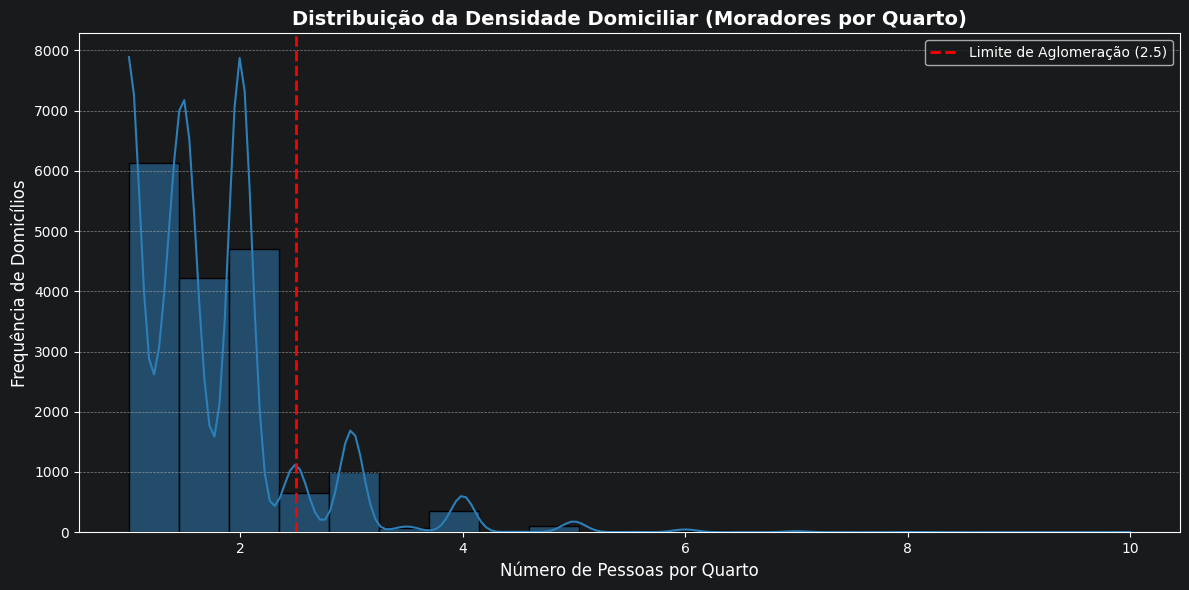

Resumo Estatístico da Densidade (Pessoas por Quarto):
count    17270.000000
mean         1.712243
std          0.742323
min          1.000000
25%          1.000000
50%          1.500000
75%          2.000000
max         10.000000
Name: densidade_morador_quarto, dtype: float64


In [46]:
# 1. Tratamento de segurança: Evitar divisão por zero
# Pessoas que moram em "quitinetes" ou vãos únicos podem ter respondido 0 para dormitórios (A011).
# Para a matemática funcionar, consideramos o vão único como 1 área de repouso.
df['A011_tratado'] = np.where(df['A011'] == 0, 1, df['A011'])

# 2. Criando as variáveis de Engenharia de Atributos
# A razão estrutural que você sugeriu
df['razao_comodos_quarto'] = df['A01001'] / df['A011_tratado']

# O indicador epidemiológico combinando os moradores
df['densidade_morador_quarto'] = df['C001'] / df['A011_tratado']

# 3. Visualizando a distribuição (Histograma)
plt.figure(figsize=(12, 6))

# Plotando a densidade de moradores por quarto
sns.histplot(df['densidade_morador_quarto'], bins=20, kde=True, color='#2c7fb8', edgecolor='black')

# Adicionando uma linha de referência para o que a OMS considera "Aglomeração" (Geralmente > 2.5 ou 3 pessoas/quarto)
plt.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='Limite de Aglomeração (2.5)')

plt.title('Distribuição da Densidade Domiciliar (Moradores por Quarto)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Pessoas por Quarto', fontsize=12)
plt.ylabel('Frequência de Domicílios', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 4. Visualizando os quartis estatísticos no console
print("Resumo Estatístico da Densidade (Pessoas por Quarto):")
print(df['densidade_morador_quarto'].describe())

In [47]:
print("Shape antes da discretização:", df.shape)

# 1. Definir as faixas epidemiológicas de densidade
condicoes_densidade = [
    (df['densidade_morador_quarto'] <= 1.0),                                          # 1 = Ideal
    (df['densidade_morador_quarto'] > 1.0) & (df['densidade_morador_quarto'] <= 2.0), # 2 = Moderada
    (df['densidade_morador_quarto'] > 2.0)                                            # 3 = Aglomeração
]

# 2. Mapeamento das categorias
categorias_densidade = [1, 2, 3]

# 3. Criar a nova variável categórica
df['perfil_densidade_quarto'] = np.select(
    condicoes_densidade,
    categorias_densidade,
    default=-1
).astype(int)

# Visualizar a distribuição
print("\nDistribuição do Perfil de Densidade (1=Ideal, 2=Moderada, 3=Aglomeração):")
print(df['perfil_densidade_quarto'].value_counts(dropna=False).sort_index())

# 4. Eliminar as colunas originais e variáveis temporárias para limpar a base
colunas_para_remover = [
    'A01001', 'A011', 'A011_tratado', 'C001',
    'razao_comodos_quarto', 'densidade_morador_quarto'
]
df.drop(inplace=True, columns=colunas_para_remover, errors='ignore')

print("\nShape após limpeza:", df.shape)

# 5. Tabulação cruzada para ver o impacto da aglomeração na asma
print("\nImpacto da Aglomeração na Asma:")


Shape antes da discretização: (17270, 56)

Distribuição do Perfil de Densidade (1=Ideal, 2=Moderada, 3=Aglomeração):
perfil_densidade_quarto
1     4616
2    10362
3     2292
Name: count, dtype: int64

Shape após limpeza: (17270, 51)

Impacto da Aglomeração na Asma:


In [48]:
pd.crosstab(df['Q074'], df['perfil_densidade_quarto'])

perfil_densidade_quarto,1,2,3
Q074,,,
1.0,582,1127,200
2.0,4034,9235,2092


* A variável `VDF004` é uma variável derivada da PNS que indica a faixa de rendimento domiciliar *per capita* (em salários mínimos), sendo um indicador socioeconômico primário.
---
* A cardinalidade original de 7 faixas foi reduzida e consolidada em uma nova variável categórica ordinal (`faixa_renda_per_capita`) com 4 níveis. Este agrupamento otimiza a separação de classes para o algoritmo preditivo, eliminando ruídos nas extremidades da distribuição de renda:
    * **1 = Até 1 salário mínimo:** Agrupa indivíduos em situação de vulnerabilidade e baixa renda (categorias originais 1, 2 e 3: até 1/4, até 1/2 e até 1 salário mínimo).
    * **2 = Mais de 1 a 2 salários mínimos:** Classe de renda média-baixa (categoria original 4).
    * **3 = Mais de 2 a 3 salários mínimos:** Classe de renda média (categoria original 5).
    * **4 = Mais de 3 salários mínimos:** Agrupa as faixas de maior poder aquisitivo (categorias originais 6 e 7: 3 a 5 SM e Mais de 5 SM), refletindo o estrato com maior acesso facilitado à saúde suplementar e qualidade habitacional.

In [49]:
print("Shape antes da transformação:", df.shape)

df.dropna(subset=['VDF004'], inplace=True)

# 1. Tratar valores nulos (Não aplicável) antes da condicional
df['VDF004'] = df['VDF004'].fillna(0)

# 2. Definir as condições lógicas para as faixas de renda agrupadas
condicoes_renda = [
    # 1 = Até 1 salário mínimo (Agrupa 1/4, 1/2 e até 1 SM)
    df['VDF004'].isin([1, 2, 3]),

    # 2 = Mais de 1 até 2 salários mínimos
    (df['VDF004'] == 4),

    # 3 = Mais de 2 até 3 salários mínimos
    (df['VDF004'] == 5),

    # 4 = Mais de 3 salários mínimos (Agrupa 3 a 5, e Mais de 5 SM)
    df['VDF004'].isin([6, 7])
]

# Categorias mapeadas
categorias_renda = [1, 2, 3, 4]

# 3. Criar a nova variável categórica
df['faixa_renda_per_capita'] = np.select(
    condicoes_renda,
    categorias_renda,
    default=-1 # Identificador de "Não aplicável" ou dados inconsistentes
).astype(int)

# Visualizar a distribuição
print("Distribuição da Renda Per Capita (1=Até 1SM, 2=1a2SM, 3=2a3SM, 4=3+SM):")
print(df['faixa_renda_per_capita'].value_counts(dropna=False).sort_index())

# 4. Eliminar a coluna original
df.drop(inplace=True, columns=['VDF004'], errors='ignore')

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17270, 51)
Distribuição da Renda Per Capita (1=Até 1SM, 2=1a2SM, 3=2a3SM, 4=3+SM):
faixa_renda_per_capita
1    8018
2    4839
3    1844
4    2558
Name: count, dtype: int64
Shape após limpeza: (17259, 51)


In [50]:
pd.crosstab(df['Q074'],df['faixa_renda_per_capita'])

faixa_renda_per_capita,1,2,3,4
Q074,,,,
1.0,836,493,234,344
2.0,7182,4346,1610,2214


* A variável `C008` (Idade do morador em anos) possui sua variância naturalmente restrita devido ao escopo metodológico do estudo, que foca exclusivamente na população adulta entre 30 e 60 anos.
---
* Para otimizar a captura do risco acumulado ao longo do tempo e mitigar ruídos de variações contínuas anuais, a idade foi discretizada em uma nova variável categórica ordinal (`faixa_etaria_adulta`), dividida em décadas epidemiológicas:
    * **1 = 30 a 39 anos:** Adultos jovens. Fase de menor acúmulo de exposições ocupacionais e ambientais prolongadas.
    * **2 = 40 a 49 anos:** Meia-idade inicial. Fase marcada por início de declínio da função pulmonar natural e, no grupo feminino, transições hormonais (perimenopausa) que afetam a reatividade brônquica.
    * **3 = 50 a 60 anos:** Meia-idade tardia. Grupo de maior vulnerabilidade tecidual, refletindo o pico de impacto do acúmulo histórico de fatores de risco ambientais, estruturais e de estilo de vida.

In [51]:
print("Shape antes da transformação:", df.shape)

# 1. Definir os limites das faixas (bins) e os rótulos
# Os limites em pd.cut() funcionam assim: (limite_inferior, limite_superior]
# Então [29, 39, 49, 60] cria: 30-39, 40-49, 50-60.
limites_idade = [29, 39, 49, 60]

# Categorias mapeadas:
# 1 = 30 a 39 anos | 2 = 40 a 49 anos | 3 = 50 a 60 anos
categorias_idade = [1, 2, 3]

# 2. Criar a nova variável categórica ordinal
df['faixa_etaria_adulta'] = pd.cut(
    df['C008'],
    bins=limites_idade,
    labels=categorias_idade,
    right=True # Garante que o limite superior está incluído na faixa
).astype(int)

# Visualizar a distribuição
print("Distribuição da Faixa Etária (1=30-39, 2=40-49, 3=50-60):")
print(df['faixa_etaria_adulta'].value_counts(dropna=False).sort_index())

# 3. Eliminar a coluna original de idade contínua
df.drop(inplace=True, columns=['C008'], errors='ignore')

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 51)
Distribuição da Faixa Etária (1=30-39, 2=40-49, 3=50-60):
faixa_etaria_adulta
1    7875
2    5520
3    3864
Name: count, dtype: int64
Shape após limpeza: (17259, 51)


In [52]:
pd.crosstab(df['Q074'],df['faixa_etaria_adulta'])

faixa_etaria_adulta,1,2,3
Q074,,,
1.0,724,619,564
2.0,7151,4901,3300


* As variáveis derivadas `VDE001` (Condição na força de trabalho) e `VDE002` (Condição de ocupação) foram utilizadas em conjunto para mapear a situação laboral do indivíduo na semana de referência da pesquisa.
---
* As informações foram consolidadas em uma única variável categórica de três níveis (`status_ocupacional`), criando um gradiente de atividade laboral que atua como proxy para vulnerabilidade econômica, nível de estresse psicossocial e o 'efeito do trabalhador saudável':
    * **1 = Ocupado:** Pessoas ativamente trabalhando (Resposta da `VDE002` == 1). Costuma agrupar indivíduos com melhor acesso à saúde suplementar e menor grau de doenças crônicas incapacitantes.
    * **2 = Desocupado:** Pessoas sem trabalho, mas buscando ativamente inserção no mercado (Resposta da `VDE002` == 2). Grupo associado a maior vulnerabilidade financeira e estresse agudo temporário.
    * **0 = Fora da Força de Trabalho:** Pessoas não ocupadas e que não buscaram trabalho (aposentados, donas de casa, pensionistas, pessoas com incapacidade permanente). Resposta "Não aplicável" / nula em `VDE002` ou `VDE001` == 2. Historicamente, concentra a maior prevalência de morbidades crônicas e limitações físicas.

In [53]:
print("Shape antes da transformação:", df.shape)

# 1. Tratar os valores nulos (Não aplicável) antes da condicional
# Quem é "Não aplicável" na VDE002 é justamente quem está FORA da força de trabalho
df['VDE002'] = df['VDE002'].fillna(0)

# 2. Definir as condições lógicas para o status ocupacional detalhado
condicoes_ocupacao = [
    (df['VDE002'] == 1), # 1 = Pessoas Ocupadas (Trabalhando)
    (df['VDE002'] == 2), # 2 = Pessoas Desocupadas (Procurando emprego)
    (df['VDE002'] == 0)  # 0 = Fora da força de trabalho (Aposentados, estudantes, etc.)
]

# Categorias mapeadas
# 1 = Ocupado | 2 = Desocupado | 0 = Fora da Força
categorias_ocupacao = [1, 2, 0]

# 3. Criar a nova variável categórica
df['status_ocupacional'] = np.select(
    condicoes_ocupacao,
    categorias_ocupacao,
    default=0
).astype(int)

# Visualizar a distribuição
print("Distribuição do Status Ocupacional (0=Fora da Força, 1=Ocupado, 2=Desocupado):")
print(df['status_ocupacional'].value_counts(dropna=False).sort_index())

# 4. Eliminar as colunas originais (limpa tanto a VDE001 quanto a VDE002)
df.drop(inplace=True, columns=['VDE001', 'VDE002'], errors='ignore')

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 51)
Distribuição do Status Ocupacional (0=Fora da Força, 1=Ocupado, 2=Desocupado):
status_ocupacional
0     2665
1    13833
2      761
Name: count, dtype: int64
Shape após limpeza: (17259, 50)


In [54]:
pd.crosstab(df['Q074'],df['status_ocupacional'])

status_ocupacional,0,1,2
Q074,,,
1.0,394,1414,99
2.0,2271,12419,662


* A variável `A009010` indica a principal forma de tratamento ou proveniência da água utilizada para beber no domicílio.
---
* A informação foi consolidada em uma nova variável categórica binária (`acesso_agua_potavel_adequada`), focada em isolar o acesso ao padrão ouro de consumo de água, servindo como um forte indicador socioeconômico e de segurança sanitária:
    * **1 = Adequada:** A água utilizada para beber é filtrada no domicílio ou é mineral industrializada (Resposta da `A009010` pertencente a `[1, 5]`). Representa o cenário ideal de infraestrutura e prevenção de doenças hídricas.
    * **0 = Não Ideal / Vulnerabilidade:** A água é fervida, tratada com hipoclorito de sódio (cloro), tratada de outras formas paliativas ou não recebe nenhum tratamento (Resposta da `A009010` pertencente a `[2, 3, 4, 6]`). Agrupa domicílios que dependem de métodos de desinfecção reativos devido à desconfiança na rede ou que estão expostos ao risco direto por falta de tratamento.

In [55]:
print("Shape antes da transformação:", df.shape)

# 1. Definir as condições lógicas para o tratamento da água de beber
condicoes_agua_beber = [
    # 1 = Adequada (Filtrada ou Mineral industrializada)
    df['A009010'].isin([1, 5]),

    # 0 = Não ideal / Vulnerável (Fervida, Cloro, Outros, ou Sem tratamento)
    df['A009010'].isin([2, 3, 4, 6])
]

# Categorias mapeadas
categorias_agua_beber = [1, 0]

# 2. Criar a nova variável binária
df['acesso_agua_potavel_adequada'] = np.select(
    condicoes_agua_beber,
    categorias_agua_beber,
    default=-1 # Identificador de nulos ou dados inconsistentes
).astype(int)

# Visualizar a distribuição
print("Distribuição da Água para Beber (0 = Não Ideal, 1 = Adequada):")
print(df['acesso_agua_potavel_adequada'].value_counts(dropna=False).sort_index())

# 3. Eliminar a coluna original
df.drop(inplace=True, columns=['A009010'], errors='ignore')

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 50)
Distribuição da Água para Beber (0 = Não Ideal, 1 = Adequada):
acesso_agua_potavel_adequada
0     4697
1    12562
Name: count, dtype: int64
Shape após limpeza: (17259, 50)


In [56]:
pd.crosstab(df['Q074'],df['acesso_agua_potavel_adequada'])

acesso_agua_potavel_adequada,0,1
Q074,,
1.0,525,1382
2.0,4172,11180


* A variável `I00102` questiona se o morador possui algum plano de saúde médico particular, de empresa ou de órgão público. A variável complementar `I001021` quantifica o número de planos, caso a resposta seja afirmativa.
---
* A informação principal foi binarizada em uma nova variável (`possui_plano_saude`), atuando como um poderoso indicador socioeconômico e de facilidade de acesso ao diagnóstico e tratamento médico especializado:
    * **1 = Sim:** O indivíduo possui cobertura de saúde suplementar (Resposta da `I00102` == 1). Representa maior probabilidade de diagnóstico formal de doenças crônicas devido ao acesso facilitado a especialistas.
    * **0 = Não:** O indivíduo depende exclusivamente da rede pública de saúde (Resposta da `I00102` == 2). Pode indicar maior vulnerabilidade socioeconômica e possível subnotificação de diagnósticos médicos especializados.

In [57]:
print("Shape antes da transformação:", df.shape)

# 1. Definir as condições lógicas para o plano de saúde
condicoes_plano = [
    (df['I00102'] == 1), # 1 = Sim
    (df['I00102'] == 2)  # 2 = Não
]

# Categorias mapeadas para padrão binário
categorias_plano = [1, 0]

# 2. Criar a nova variável binária
df['possui_plano_saude'] = np.select(
    condicoes_plano,
    categorias_plano,
    default=-1 # Identificador de nulos ou dados inconsistentes
).astype(int)

# Visualizar a distribuição
print("Distribuição de Plano de Saúde (0 = Não, 1 = Sim):")
print(df['possui_plano_saude'].value_counts(dropna=False).sort_index())

# 3. Eliminar as colunas originais (incluindo a de quantidade de planos, se existir)
df.drop(inplace=True, columns=['I00102', 'I001021'], errors='ignore')

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 50)
Distribuição de Plano de Saúde (0 = Não, 1 = Sim):
possui_plano_saude
0    12341
1     4918
Name: count, dtype: int64
Shape após limpeza: (17259, 50)


In [58]:
pd.crosstab(df['Q074'],df['possui_plano_saude'])

possui_plano_saude,0,1
Q074,,
1.0,1240,667
2.0,11101,4251


In [59]:
df.rename(columns={'C006': 'sexo', 'C009': 'raca','Q074':'Asma'}, inplace=True)
df.drop(inplace=True,columns=['Unnamed: 0','Unnamed: 0.1'])

* As variáveis do Módulo R da PNS (`R025`, `R026`, `R027`, `R028`, `R029`) abordam o histórico de menstruação e menopausa, fatores com alta correlação na literatura médica com o desenvolvimento ou agravamento de asma em pacientes do sexo feminino (impacto hormonal).
* Indivíduos do sexo masculino e mulheres com dados faltantes (devido a pulos lógicos do questionário) exigiram tratamento diferenciado para evitar confusão no particionamento do algoritmo de árvore.
---
* A variável contínua `R025` (Idade da primeira menstruação) foi padronizada (`idade_primeira_menstruacao`), imputando-se o valor estrutural `-1` para indivíduos do sexo masculino.
* As variáveis categóricas de status (`R026`, `R028` e `R029`) foram consolidadas em uma única variável ordinal de risco (`perfil_hormonal`), mapeando o estado de flutuação endócrina:
    * **-1 = Homens:** Isolamento da amostra masculina (Não aplicável).
    * **1 = Fase Reprodutiva:** Mulheres que ainda menstruam.
    * **2 = Menopausa sem TRH:** Mulheres que entraram na menopausa e nunca fizeram tratamento de reposição hormonal.
    * **3 = Menopausa com TRH:** Mulheres na menopausa que fazem ou já fizeram uso de reposição hormonal.
    * **0 = Inconclusivo:** Mulheres que não souberam responder ou com respostas inconsistentes.

In [60]:
print("Shape antes da transformação:", df.shape)

# 1. Tratamento da Idade da 1ª Menstruação
df['R025'] = np.where(df['sexo'] == 1, -1, df['R025'])
# Tratar eventuais NaNs remanescentes (mulheres que não responderam) com a mediana ou -1
df['R025'] = df['R025'].fillna(-1).astype(int)

# 2. Construção do Perfil Hormonal / Menopausa
condicoes_hormonais = [
    # -1 = Homens (Não aplicável biologicamente)
    (df['sexo'] == 1),

    # 1 = Mulher em fase reprodutiva (Ainda menstrua: R026 == 1)
    (df['sexo'] == 2) & (df['R026'] == 1),

    # 2 = Mulher na menopausa SEM reposição hormonal (R028 == 1 E R029 == 3)
    (df['sexo'] == 2) & (df['R028'] == 1) & (df['R029'] == 3),

    # 3 = Mulher na menopausa COM reposição hormonal (R028 == 1 E R029 em [1, 2])
    (df['sexo'] == 2) & (df['R028'] == 1) & (df['R029'].isin([1, 2]))
]

# Categorias mapeadas
categorias_hormonais = [-1, 1, 2, 3]

# 3. Criar a nova variável categórica
df['perfil_hormonal'] = np.select(
    condicoes_hormonais,
    categorias_hormonais,
    default=0 # 0 = Mulheres com dados inconclusivos/não souberam responder
).astype(int)

# Visualizar a distribuição
print("\nDistribuição do Perfil Hormonal:")
print(df['perfil_hormonal'].value_counts(dropna=False).sort_index())

# 4. Eliminar as colunas originais do questionário
df.drop(inplace=True, columns=['R025', 'R026', 'R027', 'R028', 'R029'], errors='ignore')

print("\nShape após limpeza:", df.shape)

Shape antes da transformação: (17259, 48)

Distribuição do Perfil Hormonal:
perfil_hormonal
-1    8536
 0     596
 1    6647
 2    1254
 3     226
Name: count, dtype: int64

Shape após limpeza: (17259, 45)


In [61]:
pd.crosstab(df['Asma'],df['perfil_hormonal'])

perfil_hormonal,-1,0,1,2,3
Asma,,,,,
1.0,655,152,793,256,51
2.0,7881,444,5854,998,175


## Variáveis de Alimentação

* São as seguintes variáveis: `['P02401', 'P02601', 'P00901', 'P01101', 'P013', 'P015', 'P02001', 'P01601', 'P018', 'P02002', 'P023', 'P02501', 'P02602', 'P02801', 'P029', 'P01001', 'P006', 'P019']`.
* São ao todo **** variáveis.
* Será feito primeiro o entendimento dos valores vazios de cada variável.
---
### Dados Ausentes

* Para a variável `P01001`, a lógica de salto vem do conjunto `[P00901, P019]`, onde o respondente só preenche a pergunta caso o registro tenha um valor maior ou igual a 5.
* Como não é possível realizar uma imputação simples para os valores menores ou iguais a 4, será feita uma imputação por cluster, utilizando as variáveis de salto, dados de alimentação e características gerais.
    * Essa imputação ressignifica a váriavel, demosntrando quantas vezes por dia a pessoa come em média tal alimento.
* Já a variável `P02401` diz respeito ao tipo de consumo de leite. Se a pessoa não consome leite, a pergunta não é aplicável; logo, será imputado o valor 0 para representar essa categoria.


In [62]:
colunas_contexto = [
    'P018', 'P00901', 'P019', 'P01001',
    'P02602', 'P02501', 'P02001', 'P02601', 'P01101', 'P015', 'P006',
    'sexo', 'nivel_educacao', 'regiao_br', 'IMC', 'faixa_renda_per_capita', 'faixa_etaria_adulta','perfil_densidade_quarto'
]
colunas_alvo = ['P019', 'P01001']

# Categoricos_ordinais = [P02601,nivel_educacao,IMC (está discretizado),salario_min (esta discrezado, por N° de salarios min)]
# Categoricos_nominais = [Sexo,regiao_br]

print(df['P019'].value_counts(dropna=False))

# --- Distribuição ANTES da imputação (para validação posterior) ---
dist_antes = {col: df[col].describe() for col in colunas_alvo}

# Isso cria colunas como 'Sexo_1', 'Sexo_2', 'regiao_br_1', 'regiao_br_2', etc.
df = pd.get_dummies(df, columns=['sexo', 'regiao_br'])

# 2. Capturamos o nome dessas novas colunas binárias criadas
colunas_dummies = [col for col in df.columns if col.startswith(('sexo_', 'regiao_br_'))]

# 3. Atualizamos a sua lista de colunas (removendo as antigas e adicionando as novas)
colunas_contexto = [
    'P018', 'P00901', 'P019', 'P01001',
    'P02602', 'P02501', 'P02001', 'P02601', 'P01101', 'P015', 'P006',
    'nivel_educacao',  'IMC', 'faixa_renda_per_capita', 'faixa_etaria_adulta','perfil_densidade_quarto'
] + colunas_dummies # <--- Somando a lista de dummies aqui

# --- Split estratificado ---
# Feito aqui e mantido para o resto da pipeline
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Asma']
)
df_train = df_train.copy()
df_test  = df_test.copy()

# --- Scaler: fit apenas no treino ---
scaler = MinMaxScaler()
train_scaled = pd.DataFrame(
    scaler.fit_transform(df_train[colunas_contexto]),
    columns=colunas_contexto,
    index=df_train.index
)
test_scaled = pd.DataFrame(
    scaler.transform(df_test[colunas_contexto]),
    columns=colunas_contexto,
    index=df_test.index
)

# --- KNN: fit apenas no treino ---
# k=10 escolhido por ser mais estável que o default (5) dado o volume de dados (~18k treino)
# weights='distance' para que vizinhos mais próximos contribuam mais
imputer = KNNImputer(n_neighbors=11, weights='distance')
train_imputed_scaled = pd.DataFrame(
    imputer.fit_transform(train_scaled),
    columns=colunas_contexto,
    index=df_train.index
)
test_imputed_scaled = pd.DataFrame(
    imputer.transform(test_scaled),
    columns=colunas_contexto,
    index=df_test.index
)

# --- Reverter escala ---
train_original = pd.DataFrame(
    scaler.inverse_transform(train_imputed_scaled),
    columns=colunas_contexto,
    index=df_train.index
)
test_original = pd.DataFrame(
    scaler.inverse_transform(test_imputed_scaled),
    columns=colunas_contexto,
    index=df_test.index
)

# --- Devolver valores imputados aos splits (não ao df original) ---
for col in colunas_alvo:
    df_train[col] = train_original[col].round().astype(int)
    df_test[col]  = test_original[col].round().astype(int)

df_imputado_completo = pd.concat([df_train[colunas_alvo], df_test[colunas_alvo]])

# Atualiza as colunas no df original
df.update(df_imputado_completo)

# Validação rápida para garantir que não há mais nulos no df original
print(f"Nulos em P01001 no DF original: {df['P01001'].isna().sum()}")
print(f"Nulos em P019 no DF original: {df['P019'].isna().sum()}")

print(df['P019'].value_counts())

P019
NaN    9487
1.0    4195
2.0    2761
3.0     816
Name: count, dtype: int64
Nulos em P01001 no DF original: 0
Nulos em P019 no DF original: 0
P019
1.0    10007
2.0     6436
3.0      816
Name: count, dtype: int64


In [63]:
# ==========================================
# REVERTENDO OS DUMMIES PARA COLUNA ORIGINAL
# ==========================================

# 1. Revertendo a variável 'Sexo'
# Captura as colunas referentes ao Sexo (Sexo_1.0, Sexo_2.0, etc.)
cols_sexo = [col for col in df.columns if col.startswith('sexo_')]

# Pega o nome da coluna que tem o valor máximo (1) na linha, apaga o prefixo e converte para número
df['sexo'] = df[cols_sexo].idxmax(axis=1).str.replace('sexo_', '').astype(float)

# Apaga as colunas dummies antigas
df = df.drop(columns=cols_sexo)


# 2. Revertendo a variável 'regiao_br'
# Captura as colunas referentes à região
cols_regiao = [col for col in df.columns if col.startswith('regiao_br_')]

# Pega o nome da coluna que tem o valor 1, apaga o prefixo e converte para inteiro
df['regiao_br'] = df[cols_regiao].idxmax(axis=1).str.replace('regiao_br_', '').astype(int)

# Apaga as colunas dummies antigas
df = df.drop(columns=cols_regiao)

# ==========================================
# Validação Rápida
# ==========================================
print("Variável Sexo restaurada:")
print(df['sexo'].value_counts())

print("\nVariável Região restaurada:")
print(df['regiao_br'].value_counts())

Variável Sexo restaurada:
sexo
2.0    8723
1.0    8536
Name: count, dtype: int64

Variável Região restaurada:
regiao_br
2    5028
3    4210
1    3235
4    2458
5    2328
Name: count, dtype: int64


## Arquitetura do Score de Qualidade Alimentar (Classificação NOVA)

Para criar um indicador robusto do perfil nutricional sem permitir que o maior número de perguntas sobre alimentos saudáveis gerasse um viés matemático, foi desenhada uma **Pipeline com Centralização por Grupos**.

### Componentes e Pesos Teóricos
1.  **Grupo 1 (In Natura / Minimamente Processados):** `P006`, `P01101`, `P013`, `P015`, `P023` + Variáveis compostas de densidade diária (`P0091` e `P0189`). **Peso do Grupo: +1.5**
2.  **Grupo 3 (Alimentos Processados):** `P01601` (Suco natural - considerando adição de açúcar/adoçante). **Peso do Grupo: -0.5**
3.  **Grupo 4 (Ultraprocessados):** `P02501`, `P02602` + variáveis de bebidas industriais (`P02001`, `P02002`) modificadas pelos seus respectivos tipos (`P02101`, `P02102`) onde a versão *Diet/Light* recebe penalidade atenuada. **Peso do Grupo: -1.5**

### Mecânica de Cálculo
* Todas as variáveis individuais são normalizadas para a escala `[0, 1]` dividindo pelo seu teto teórico.
* Calcula-se a **média aritmética interna** de cada um dos três grupos (gerando índices independentes de 0 a 1).
* **Equação Final:** $\text{Score} = (1.5 \times \text{Índice}_{G1}) - (0.5 \times \text{Índice}_{G3}) - (1.5 \times \text{Índice}_{G4})$
* **Intervalo Teórico do Score:** `[-2.0, +1.5]`

### Discretização Final (`perfil_alimentacao`)
Foi feita uma análise da distribuição do Score, e constatou-se que os dados seguem uma distribuição normal. Para garantir a robustez metodológica na separação dos perfis, optou-se por abandonar cortes manuais heurísticos e adotar limites estatísticos baseados no **Z-Score** da amostra, utilizando **1 Desvio Padrão ($1\sigma$)** em relação à Média ($\mu$).

O particionamento gerou as seguintes categorias:

* **`1` = Dieta Precária:** Indivíduos com Score $< \mu - 1\sigma$. Representa a cauda inferior da distribuição (aproximadamente 16% da população estatística), englobando os perfis com maior dependência de alimentos ultraprocessados e que apresentam um desvio negativo significativo em relação ao comportamento alimentar médio.
* **`2` = Dieta Balanceada:** Indivíduos com Score entre $\mu - 1\sigma$ e $\mu + 1\sigma$. Consiste no "miolo" central da distribuição normal (aproximadamente 68% da população). Reflete o padrão de consumo *baseline* da amostra, caracterizado por uma dieta híbrida e intermediária entre itens *in natura* e processados.
* **`3` = Dieta Saudável:** Indivíduos com Score $> \mu + 1\sigma$. Representa a cauda superior da distribuição normal (aproximadamente 16% da população estatística), isolando os indivíduos que possuem uma forte e rigorosa predominância de consumo de alimentos *In Natura* e minimamente processados, destacando-se positivamente do restante da amostra.

In [64]:
print(df.shape)
pd.set_option('display.max_rows', None)
# --- PASSO 1: Engenharia de Recursos (Densidade de Consumo) ---
# Multiplica dias por vezes ao dia e divide por 7
df['P0091'] = (df['P00901'] * df['P01001']) / 7
df['P0189'] = (df['P018'] * df['P019']) / 7

# --- PASSO 2: Centralização do Grupo 1 (In Natura) ---
g1_puros = ['P006', 'P01101', 'P013', 'P015', 'P023']
g1_norm = pd.DataFrame(index=df.index)

# Normaliza variáveis de dias puros (0 a 7 -> 0 a 1)
for var in g1_puros:
    g1_norm[var] = df[var] / 7

# Normaliza as variáveis compostas (0 a 3 -> 0 a 1)
g1_norm['P0091'] = df['P0091'] / 3
g1_norm['P0189'] = df['P0189'] / 3

# Extrai a média do grupo (Índice de 0 a 1)
df['indice_g1'] = g1_norm.mean(axis=1)

# --- PASSO 3: Centralização do Grupo 3 (Processados) ---
df['indice_g3'] = df['P01601'] / 7

# --- PASSO 4: Centralização do Grupo 4 (Ultraprocessados com Modificadores) ---
# Dicionário mapeia o peso relativo de cada tipo dentro da penalidade do grupo
fator_tipo = {
    1: (1.0 / 1.5),   # Diet/Light/Zero atenua para -1.0
    2: 1.0,           # Normal mantém penalidade cheia -1.5
    3: (1.25 / 1.5)   # Ambos fica no intermediário -1.25
}

# Cria os modificadores (caso seja nulo devido ao pulo, assume peso padrão 1.0)
mod_suco = df['P02101'].map(fator_tipo).fillna(1.0)
mod_refri = df['P02102'].map(fator_tipo).fillna(1.0)

g4_norm = pd.DataFrame(index=df.index)
g4_norm['P02501'] = df['P02501'] / 7
g4_norm['P02602'] = df['P02602'] / 7
g4_norm['P02001'] = (df['P02001'] / 7) * mod_suco
g4_norm['P02002'] = (df['P02002'] / 7) * mod_refri

# Extrai a média do grupo (Índice de 0 a 1)
df['indice_g4'] = g4_norm.mean(axis=1)

# --- PASSO 5: Cálculo do Score Final Ponderado ---
# O intervalo resultante vai de -2.0 a +1.5
df['score_nova'] = (1.5 * df['indice_g1']) - ( 0.5 * df['indice_g3']) - (1.5 * df['indice_g4'])


(17259, 45)


In [65]:
# Correlação de Spearman (ideal para variáveis ordinais/contínuas não lineares)
correlacao = df[['score_nova', 'IMC']].corr(method='spearman')
print("Correlação entre Qualidade da Dieta e IMC:")
display(correlacao)

Correlação entre Qualidade da Dieta e IMC:


,score_nova,IMC
score_nova,1.000000,-0.011568
IMC,-0.011568,1.000000


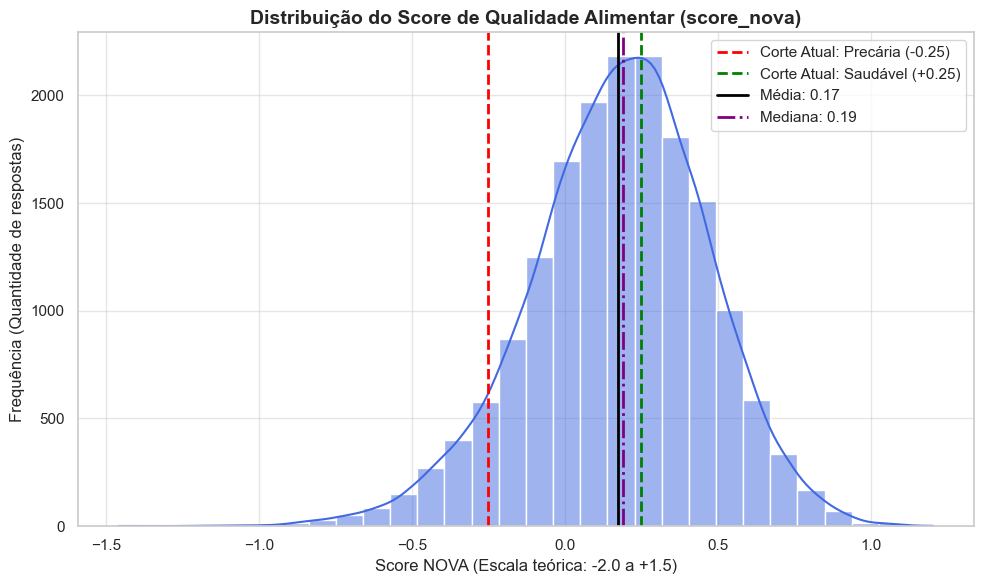

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo visual do gráfico
sns.set_theme(style="whitegrid")

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Cria o histograma com a curva de densidade (KDE)
# 'bins' define o número de "barras". Você pode ajustar para 20 ou 40 dependendo do volume de dados.
sns.histplot(data=df, x='score_nova', bins=30, kde=True, color='royalblue')

# --- ADICIONANDO LINHAS DE REFERÊNCIA ---

# Linhas para os seus cortes heurísticos atuais
plt.axvline(x=-0.25, color='red', linestyle='--', linewidth=2, label='Corte Atual: Precária (-0.25)')
plt.axvline(x=0.25, color='green', linestyle='--', linewidth=2, label='Corte Atual: Saudável (+0.25)')

# Linhas para estatísticas descritivas (Média e Mediana)
media = df['score_nova'].mean()
mediana = df['score_nova'].median()

plt.axvline(x=media, color='black', linestyle='-', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(x=mediana, color='purple', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.2f}')

# --- CUSTOMIZAÇÃO DE TEXTOS E RÓTULOS ---
plt.title('Distribuição do Score de Qualidade Alimentar (score_nova)', fontsize=14, fontweight='bold')
plt.xlabel('Score NOVA (Escala teórica: -2.0 a +1.5)', fontsize=12)
plt.ylabel('Frequência (Quantidade de respostas)', fontsize=12)

# Exibe a legenda para identificar as linhas
plt.legend(loc='upper right')

# Renderiza o gráfico
plt.tight_layout()
plt.show()

In [67]:
# 1. Calcula a Média e o Desvio Padrão da população
media = df['score_nova'].mean()
desvio_padrao = df['score_nova'].std()

# 2. Define os cortes baseados na Regra Empírica (Z-Score = 1)
corte_inferior = media - desvio_padrao
corte_superior = media + desvio_padrao

# (Opcional) Imprimir os valores exatos dos cortes para sua validação
print(f"Média: {media:.4f} | Desvio Padrão (1σ): {desvio_padrao:.4f}")
print(f"Corte Inferior (-1σ): {corte_inferior:.4f}")
print(f"Corte Superior (+1σ): {corte_superior:.4f}\n")

# 3. Aplica a discretização com base nos cortes calculados
condicoes_score = [
    (df['score_nova'] < corte_inferior),
    (df['score_nova'].between(corte_inferior, corte_superior)),
    (df['score_nova'] > corte_superior)
]

categorias_score = [1, 2, 3]

# Atualiza a coluna no dataframe
df['perfil_alimentacao'] = np.select(condicoes_score, categorias_score, default=2).astype(int)

# 4. Visualiza os resultados finais
print("Distribuição do perfil de alimentação (Z-Score):")
print(df['perfil_alimentacao'].value_counts().sort_index())

# --- PASSO 7: Limpeza do Dataset ---
# Remove as colunas brutas do questionário e os índices/scores intermediários,
# deixando apenas a classificação final (perfil_alimentacao) para o modelo.

colunas_para_remover = [
    'P006', 'P00901', 'P01001', 'P01101', 'P013', 'P015', 'P01601', 'P018', 'P019',
    'P02001', 'P02002', 'P02101', 'P02102', 'P023', 'P02401', 'P02501', 'P02601', 'P02602',
    'P0091', 'P0189', 'indice_g1', 'indice_g3', 'indice_g4'
]

df.drop(columns=colunas_para_remover, inplace=True)

# Visualizar o formato final do dataset após a limpeza
print(f"Formato final do Dataset após consolidar a alimentação: {df.shape}")

Média: 0.1746 | Desvio Padrão (1σ): 0.2915
Corte Inferior (-1σ): -0.1168
Corte Superior (+1σ): 0.4661

Distribuição do perfil de alimentação (Z-Score):
perfil_alimentacao
1     2619
2    12029
3     2611
Name: count, dtype: int64
Formato final do Dataset após consolidar a alimentação: (17259, 29)


In [68]:
pd.crosstab(df['Asma'],df['perfil_alimentacao'])

perfil_alimentacao,1,2,3
Asma,,,
1.0,329,1287,291
2.0,2290,10742,2320


* As variáveis do Módulo P da PNS referentes à frequência de consumo de bebidas alcoólicas (`P027` e `P02801`) foram utilizadas para construir um indicador de exposição. A variável de volume de doses (`P029`) foi descartada para evitar viés de subnotificação comum em inquéritos de autorrelato.
* A lógica de saltos do questionário foi equalizada em uma variável temporal contínua (`dias_equivalentes_semana`), transformando o consumo mensal em uma média fracionada de dias por semana.
---
* A frequência contínua foi discretizada em uma nova variável categórica ordinal (`perfil_alcool`), mapeando o hábito e a exposição sistêmica:
    * **1 = Abstêmio:** Indivíduos que relataram nunca consumir bebidas alcoólicas (Resposta da `P027` == 1).
    * **2 = Consumo Ocasional:** Consumo estimado entre > 0 e até 2 dias equivalentes por semana. Agrupa bebedores sociais esporádicos e o padrão clássico de consumo aos finais de semana.
    * **3 = Consumo Frequente / Habitual:** Consumo ocorrendo de 3 a 7 dias por semana. Indica maior constância na ingestão, o que do ponto de vista sistêmico representa inflamação hepática e metabólica mais recorrente, potencialmente afetando interações medicamentosas e respostas imunes.

In [69]:
print("Shape antes da transformação:", df.shape)

# 1. Tratar valores nulos iniciais para evitar quebras lógicas
df['P02801'] = df['P02801'].fillna(0)

# 2. Definir as condições para estimar os Dias Equivalentes por Semana
condicoes_alcool = [
    (df['P027'] == 1),                               # Não bebe nunca -> 0 dias
    (df['P027'] == 2),                               # Menos de uma vez por mês -> 0.125 dias (1/8 de semana)
    (df['P027'] == 3) & (df['P02801'] == 0),         # Uma vez ou mais por mês, mas < 1x por semana -> 0.5 dias
    (df['P027'] == 3) & (df['P02801'] >= 1)          # Consumo semanal fixo -> Usa o próprio número de dias relatado (1 a 7)
]

valores_dias = [
    0.0,
    0.125,
    0.5,
    df['P02801']
]

# Criar a variável intermediária contínua de frequência de dias na semana
df['dias_equivalentes_semana'] = np.select(condicoes_alcool, valores_dias, default=0.0)

# 3. Discretização Numérica em Categorias de Frequência
condicoes_discreta = [
    (df['dias_equivalentes_semana'] == 0),                                           # Abstêmio
    (df['dias_equivalentes_semana'] > 0) & (df['dias_equivalentes_semana'] <= 2.0),  # Consumo Ocasional/Final de Semana (Até 2 dias)
    (df['dias_equivalentes_semana'] > 2.0)                                           # Consumo Frequente/Regular (3 a 7 dias)
]

# Mapeamento de 'perfil_alcool':
# 1 = Abstêmio / Não consome
# 2 = Consumo Ocasional (Até 2 dias/semana)
# 3 = Consumo Frequente (Mais de 2 dias/semana)
categorias_alcool = [1, 2, 3]

df['perfil_alcool'] = np.select(condicoes_discreta, categorias_alcool, default=1).astype(int)

# 4. Limpeza do dataset (remover variáveis originais)
# Incluindo a P029 no drop por segurança, caso ela ainda esteja no DataFrame
colunas_para_remover = ['P027', 'P02801', 'P029', 'dias_equivalentes_semana']
df.drop(inplace=True, columns=colunas_para_remover, errors='ignore')

# Visualizar a distribuição do novo indicador discreto
print("Distribuição do Perfil de Consumo de Álcool (Por Frequência):")
print(df['perfil_alcool'].value_counts(dropna=False).sort_index())

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 29)
Distribuição do Perfil de Consumo de Álcool (Por Frequência):
perfil_alcool
1    9106
2    7095
3    1058
Name: count, dtype: int64
Shape após limpeza: (17259, 28)


In [70]:
pd.crosstab(df['Asma'],df['perfil_alcool'])

perfil_alcool,1,2,3
Asma,,,
1.0,987,803,117
2.0,8119,6292,941


* A variavel `perfil_exercicio` se refere ao perfil de prática de atividade física ou esporte do registro.
---
* Ele possui inicialmente dados distribuídos em 4 variáveis originais com lógicas de salto (`P034`, `P035`, `P03701`, `P03702`), sendo feita uma engenharia de recursos para consolidar o volume em minutos semanais e discretizar o resultado em 3 categorias.
* As categorias são:
    * Inativo: `minutos_semanais_exercicio == 0` (Mapeado como Código 1)
        * *Justificativa:* Agrupa os respondentes que declararam não ter praticado exercícios nos últimos três meses (`P034 == 2`) ou que informaram uma frequência de dias nula (`P035 == 0`), representando a ausência dessa prática regular no estilo de vida.
    * Insuficientemente Ativo: `0 < minutos_semanais_exercicio < 150` (Mapeado como Código 2)
        * *Justificativa:* Mapeia os indivíduos que possuem o hábito de se exercitar ao longo da semana, mas cujo volume total ponderado de tempo fica abaixo do limiar mínimo ideal de proteção.
    * Ativo: `minutos_semanais_exercicio >= 150` (Mapeado como Código 3)
        * *Justificativa:* Consolida quem atinge ou supera a diretriz oficial da Organização Mundial da Saúde (OMS) de pelo menos 150 minutos de atividade física semanal moderada a intensa, agindo como um marcador direto de proteção metabólica e redução de risco para doenças crônicas.
* As variáveis de suporte e de tempo bruto são descartadas ao final do processo para garantir o correto balanceamento e a não-colinearidade nos algoritmos.

In [71]:
print("Shape antes da transformação:", df.shape)

# 1. Tratar valores nulos para evitar quebras lógicas
df['P035'] = df['P035'].fillna(0)

# 2. Discretização Numérica Baseada na Frequência (Dias por Semana)
condicoes_exercicio = [
    # 1 = Inativo (Não pratica ou 0 dias)
    (df['P034'] == 2) | (df['P035'] == 0),

    # 2 = Ocasional / Irregular (1 a 2 dias por semana)
    (df['P034'] == 1) & (df['P035'] > 0) & (df['P035'] <= 2),

    # 3 = Regular / Ativo (3 ou mais dias por semana)
    (df['P034'] == 1) & (df['P035'] >= 3)
]

# Mapeamento de 'perfil_exercicio':
# 1 = Inativo
# 2 = Ocasional (1 a 2 dias)
# 3 = Regular (3+ dias)
categorias_exercicio = [1, 2, 3]

# 3. Criar a nova variável categórica
df['perfil_exercicio'] = np.select(condicoes_exercicio, categorias_exercicio, default=1).astype(int)

# 4. Limpeza do dataset (Remover colunas de suporte e originais)
# As variáveis P03701 e P03702 entram no drop por segurança
colunas_para_remover = ['P034', 'P035', 'P03701', 'P03702']
df.drop(inplace=True, columns=colunas_para_remover, errors='ignore')

# Visualizar a distribuição do novo indicador discreto
print("Distribuição do Perfil de Exercício Físico (Por Frequência):")
print(df['perfil_exercicio'].value_counts(dropna=False).sort_index())

print("Shape após limpeza:", df.shape)

Shape antes da transformação: (17259, 28)
Distribuição do Perfil de Exercício Físico (Por Frequência):
perfil_exercicio
1    9270
2    2637
3    5352
Name: count, dtype: int64
Shape após limpeza: (17259, 27)


In [72]:
pd.crosstab(df['Asma'],df['perfil_exercicio'])

perfil_exercicio,1,2,3
Asma,,,
1.0,1024,260,623
2.0,8246,2377,4729


In [73]:
df.columns

Index(['raca', 'Asma', 'P04001', 'Natureza_Trabalho', 'IMC',
       'Exercício pesado trabalho', 'perfil_tabagismo', 'acesso_rede_agua',
       'Exercicio_domestico', 'perfil_animal_pelo', 'exposicao_trabalho',
       'acesso_rede_esgoto', 'nivel_educacao', 'perfil_saude_mental',
       'perfil_densidade_quarto', 'faixa_renda_per_capita',
       'faixa_etaria_adulta', 'status_ocupacional',
       'acesso_agua_potavel_adequada', 'possui_plano_saude', 'perfil_hormonal',
       'sexo', 'regiao_br', 'score_nova', 'perfil_alimentacao',
       'perfil_alcool', 'perfil_exercicio'],
      dtype='object')

In [74]:
df_copy = df.copy()

df_copy.to_csv(r'../Arquivos Csv/Etapa5.csv')

ETAPA 9 — BALANCED FOLD UNDERSAMPLING + BALANCED BAGGING

Features   : 24
Registros  : 17259
Asmáticos  : 1907
Saudáveis  : 15352
Proporção  : 1:8.1

--- Configuração dos Folds Balanceados ---
Asmáticos (fixo por fold) : 1907
Saudáveis totais          : 15352
Folds possíveis (K)       : 8  (8 × 1907 = 15256)
Resto descartado          : 96 registros
Ratio por fold            : 1:1 (perfeitamente balanceado)

Folds criados: 8
  Fold  0: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  1: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  2: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  3: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  4: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  5: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  6: 1907 saudáveis + 1907 asmáticos = 3814 total
  Fold  7: 1907 saudáveis + 1907 asmáticos = 3814 total

AVALIAÇÃO DE CADA FOLD (RF como seletor)

Fold  0 | AUC: 0.6926 ± 0.0124 | F1-macro: 0.6405 | Recall Asmático: 0.6088 | Pre

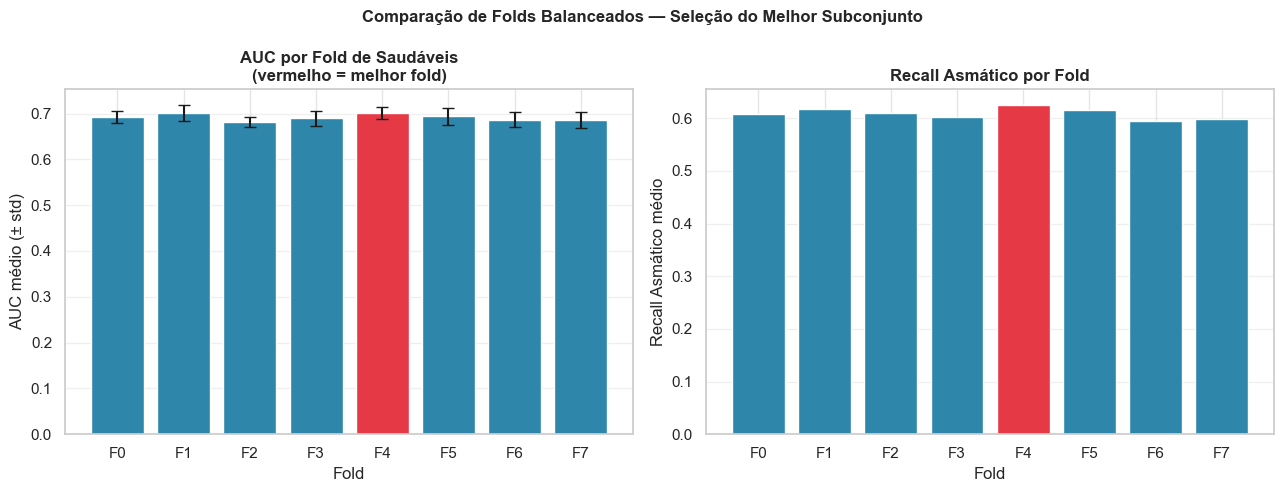


Dataset do melhor fold:
  Total     : 3814
  Asmáticos : 1907
  Saudáveis : 1907
  Ratio     : 1:1.0

BALANCED BAGGING — Stratified K-Fold (k=5) no melhor fold

Fold 1 | AUC: 0.6927 | F1-macro: 0.6597 | Recall Asmático: 0.6099 | Precision Asmático: 0.6793
Fold 2 | AUC: 0.6850 | F1-macro: 0.6142 | Recall Asmático: 0.5785 | Precision Asmático: 0.6243
Fold 3 | AUC: 0.6899 | F1-macro: 0.6315 | Recall Asmático: 0.6089 | Precision Asmático: 0.6374
Fold 4 | AUC: 0.7173 | F1-macro: 0.6627 | Recall Asmático: 0.6273 | Precision Asmático: 0.6751
Fold 5 | AUC: 0.7176 | F1-macro: 0.6667 | Recall Asmático: 0.6640 | Precision Asmático: 0.6675

=== RESULTADO FINAL — MÉDIA ± STD (5 folds) ===

  auc                       0.7005 ± 0.0141
  f1_macro                  0.6470 ± 0.0205
  recall_asmatico           0.6177 ± 0.0280
  precision_asmatico        0.6567 ± 0.0219
  recall_saudavel           0.6770 ± 0.0241
  precision_saudavel        0.6394 ± 0.0208

=== CLASSIFICATION REPORT (Out-of-Fold) ===
    

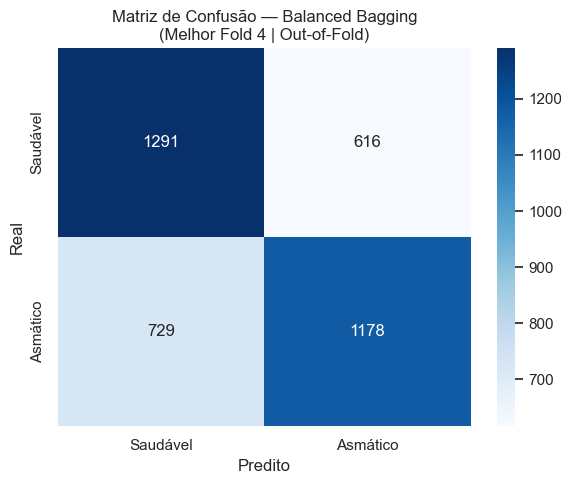


--- Calculando Curva ROC com IC Bootstrap (n=1000) ---
AUC OOF: 0.7000 | IC 95%: [0.6835, 0.7174]


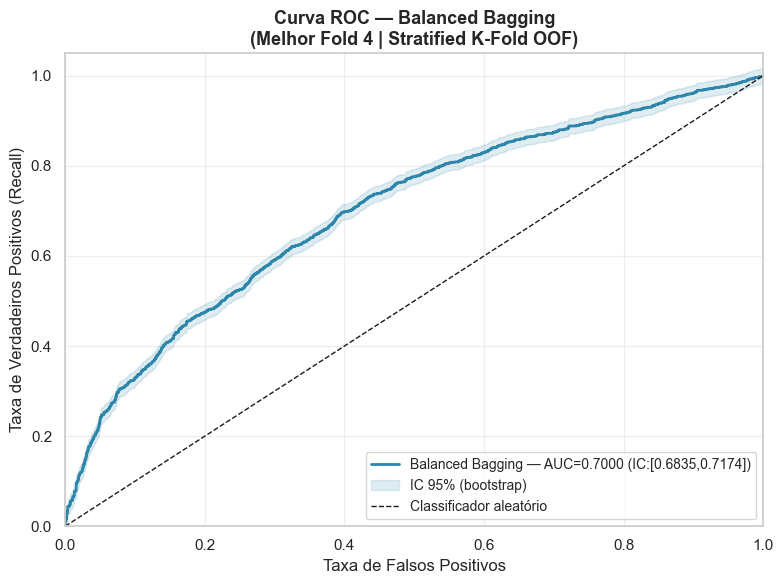


=== THRESHOLD ÓTIMO: 0.3787 ===
              precision    recall  f1-score   support

    Saudável       0.71      0.37      0.48      1907
    Asmático       0.57      0.85      0.69      1907

    accuracy                           0.61      3814
   macro avg       0.64      0.61      0.59      3814
weighted avg       0.64      0.61      0.59      3814


--- Treinando modelo final para importância de features ---

=== IMPORTÂNCIA DE FEATURES — Balanced Bagging ===
                     Feature  Importancia
                   regiao_br     0.074888
                         IMC     0.068266
              nivel_educacao     0.058883
         perfil_saude_mental     0.058235
            perfil_tabagismo     0.052924
         faixa_etaria_adulta     0.052702
      faixa_renda_per_capita     0.051192
           Natureza_Trabalho     0.049605
             perfil_hormonal     0.048609
                        raca     0.044941
            perfil_exercicio     0.043648
   Exercício pesado tra

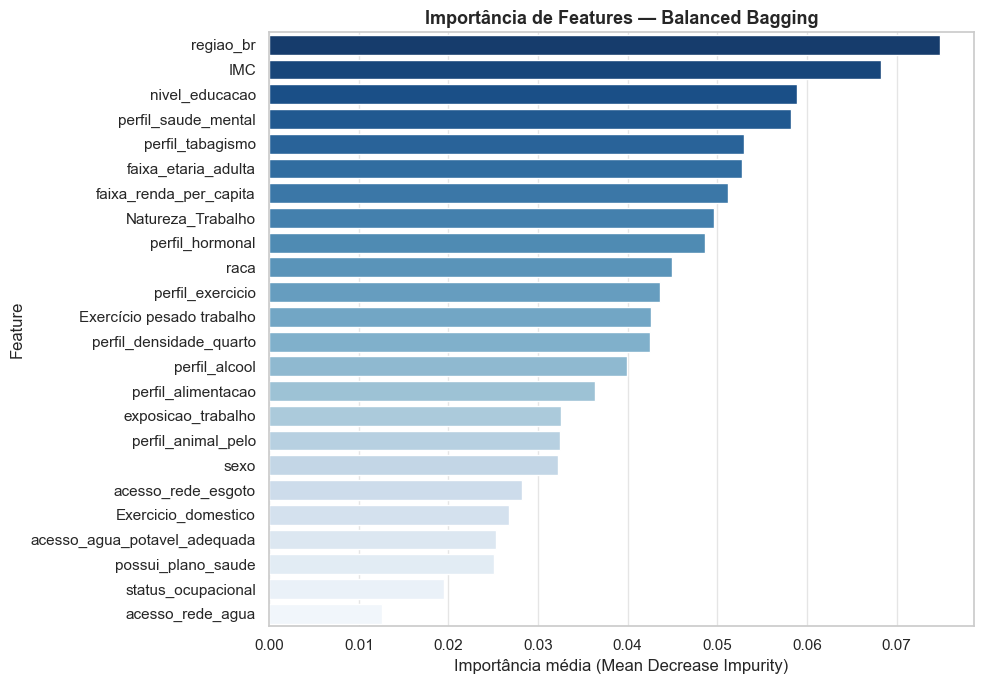


=== ARQUIVOS SALVOS ===
  avaliacao_folds_balanceados.csv
  metricas_balanced_bagging.csv
  importancia_features_bbc.csv
  comparacao_folds.png
  matriz_confusao_bbc.png
  curva_roc_bbc.png
  importancia_features_bbc.png

Etapa 9 concluída.


In [75]:
# =============================================================================
# ETAPA 9 — BALANCED FOLD UNDERSAMPLING + BALANCED BAGGING CLASSIFIER
# =============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score,
    precision_recall_curve
)
from imblearn.ensemble import BalancedBaggingClassifier

# =============================================================================
# CARREGAMENTO
# =============================================================================

df = pd.read_csv(r'../Arquivos Csv/Etapa5.csv')
cols_aux = [c for c in df.columns if 'Unnamed' in str(c)]
df = df.drop(columns=cols_aux)

y = (df['Asma'] == 1).astype(int)

# Features conforme o código enviado
FEATURES = ['raca', 'Natureza_Trabalho', 'IMC',
       'Exercício pesado trabalho', 'perfil_tabagismo', 'acesso_rede_agua',
       'Exercicio_domestico', 'perfil_animal_pelo', 'exposicao_trabalho',
       'acesso_rede_esgoto', 'nivel_educacao', 'perfil_saude_mental',
       'perfil_densidade_quarto', 'faixa_renda_per_capita',
       'faixa_etaria_adulta', 'status_ocupacional',
       'acesso_agua_potavel_adequada', 'possui_plano_saude', 'perfil_hormonal',
       'sexo', 'regiao_br', 'perfil_alimentacao', 'perfil_alcool',
       'perfil_exercicio']

X = df[FEATURES].copy()
for col in X.columns:
    if X[col].isna().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

print("=" * 60)
print("ETAPA 9 — BALANCED FOLD UNDERSAMPLING + BALANCED BAGGING")
print("=" * 60)
print(f"\nFeatures   : {len(FEATURES)}")
print(f"Registros  : {len(y)}")
print(f"Asmáticos  : {y.sum()}")
print(f"Saudáveis  : {(y==0).sum()}")
print(f"Proporção  : 1:{round((y==0).sum()/y.sum(),1)}")

# =============================================================================
# ETAPA 1 — SEPARAR ASMÁTICOS E DIVIDIR SAUDÁVEIS EM FOLDS BALANCEADOS
# =============================================================================

X_arr = X.values
y_arr = y.values

idx_asma  = np.where(y_arr == 1)[0]
idx_saud  = np.where(y_arr == 0)[0]

N_ASMA = len(idx_asma)
N_SAUD = len(idx_saud)

K_FOLDS_SAUD = N_SAUD // N_ASMA
RESTO        = N_SAUD % N_ASMA

print(f"\n--- Configuração dos Folds Balanceados ---")
print(f"Asmáticos (fixo por fold) : {N_ASMA}")
print(f"Saudáveis totais          : {N_SAUD}")
print(f"Folds possíveis (K)       : {K_FOLDS_SAUD}  ({K_FOLDS_SAUD} × {N_ASMA} = {K_FOLDS_SAUD*N_ASMA})")
print(f"Resto descartado          : {RESTO} registros")
print(f"Ratio por fold            : 1:1 (perfeitamente balanceado)")

rng = np.random.RandomState(42)
idx_saud_shuffled = rng.permutation(idx_saud)

folds_saudaveis = [
    idx_saud_shuffled[i * N_ASMA : (i + 1) * N_ASMA]
    for i in range(K_FOLDS_SAUD)
]

print(f"\nFolds criados: {len(folds_saudaveis)}")
for i, fold in enumerate(folds_saudaveis):
    print(f"  Fold {i:>2}: {len(fold)} saudáveis + {N_ASMA} asmáticos = {len(fold)+N_ASMA} total")

# =============================================================================
# ETAPA 2 — AVALIAR CADA FOLD COM RF + STRATIFIED K-FOLD INTERNO
# =============================================================================

print(f"\n{'='*60}")
print(f"AVALIAÇÃO DE CADA FOLD (RF como seletor)")
print(f"{'='*60}\n")

rf_seletor = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

skf_interno = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_folds = []

for i, idx_fold_saud in enumerate(folds_saudaveis):

    idx_fold = np.concatenate([idx_asma, idx_fold_saud])
    X_fold   = X_arr[idx_fold]
    y_fold   = y_arr[idx_fold]

    aucs, f1s, recs, precs = [], [], [], []

    for idx_tr, idx_val in skf_interno.split(X_fold, y_fold):
        X_tr, X_val = X_fold[idx_tr], X_fold[idx_val]
        y_tr, y_val = y_fold[idx_tr], y_fold[idx_val]

        rf_seletor.fit(X_tr, y_tr)
        y_prob = rf_seletor.predict_proba(X_val)[:, 1]
        y_pred = rf_seletor.predict(X_val)

        aucs.append(roc_auc_score(y_val, y_prob))
        f1s.append(f1_score(y_val, y_pred, average='macro'))
        recs.append(recall_score(y_val, y_pred, pos_label=1))
        precs.append(precision_score(y_val, y_pred, pos_label=1, zero_division=0))

    resultado = {
        'fold'                : i,
        'auc_media'           : np.mean(aucs),
        'auc_std'             : np.std(aucs),
        'f1_macro_media'      : np.mean(f1s),
        'recall_asma_media'   : np.mean(recs),
        'precision_asma_media': np.mean(precs),
        'n_total'             : len(idx_fold)
    }
    resultados_folds.append(resultado)

    print(f"Fold {i:>2} | AUC: {resultado['auc_media']:.4f} ± {resultado['auc_std']:.4f} | "
          f"F1-macro: {resultado['f1_macro_media']:.4f} | "
          f"Recall Asmático: {resultado['recall_asma_media']:.4f} | "
          f"Precision Asmático: {resultado['precision_asma_media']:.4f}")

df_resultados = pd.DataFrame(resultados_folds)

# =============================================================================
# ETAPA 3 — SELECIONAR O MELHOR FOLD
# =============================================================================

idx_melhor  = df_resultados['auc_media'].idxmax()
melhor_fold = df_resultados.loc[idx_melhor]

print(f"\n{'='*60}")
print(f"MELHOR FOLD SELECIONADO: Fold {int(melhor_fold['fold'])}")
print(f"{'='*60}")
print(f"  AUC média          : {melhor_fold['auc_media']:.4f} ± {melhor_fold['auc_std']:.4f}")
print(f"  F1-macro           : {melhor_fold['f1_macro_media']:.4f}")
print(f"  Recall Asmático    : {melhor_fold['recall_asma_media']:.4f}")
print(f"  Precision Asmático : {melhor_fold['precision_asma_media']:.4f}")

# Visualização dos folds
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cores = ['#E63946' if i == int(melhor_fold['fold']) else '#2E86AB'
         for i in df_resultados['fold']]

axes[0].bar(
    [f'F{i}' for i in df_resultados['fold']],
    df_resultados['auc_media'],
    yerr=df_resultados['auc_std'],
    color=cores, edgecolor='white', capsize=4
)
axes[0].set_title('AUC por Fold de Saudáveis\n(vermelho = melhor fold)', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC médio (± std)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(
    [f'F{i}' for i in df_resultados['fold']],
    df_resultados['recall_asma_media'],
    color=cores, edgecolor='white'
)
axes[1].set_title('Recall Asmático por Fold', fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Recall Asmático médio')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparação de Folds Balanceados — Seleção do Melhor Subconjunto',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Arquivos Csv/comparacao_folds.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# ETAPA 4 — MONTAR DATASET DO MELHOR FOLD
# =============================================================================

best_fold_idx = int(melhor_fold['fold'])
idx_best      = np.concatenate([idx_asma, folds_saudaveis[best_fold_idx]])
X_best        = X_arr[idx_best]
y_best        = y_arr[idx_best]

print(f"\nDataset do melhor fold:")
print(f"  Total     : {len(y_best)}")
print(f"  Asmáticos : {y_best.sum()}")
print(f"  Saudáveis : {(y_best==0).sum()}")
print(f"  Ratio     : 1:{round((y_best==0).sum()/y_best.sum(),2)}")

# =============================================================================
# ETAPA 5 — BALANCED BAGGING NO MELHOR FOLD
# =============================================================================

bbc = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(
        n_estimators=50,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    n_estimators=20,
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_jobs=-1
)

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas_finais = {
    'auc': [], 'f1_macro': [],
    'recall_asmatico': [], 'precision_asmatico': [],
    'recall_saudavel': [], 'precision_saudavel': []
}

y_prob_oof = np.zeros(len(y_best))
y_pred_oof = np.zeros(len(y_best), dtype=int)

print(f"\n{'='*60}")
print(f"BALANCED BAGGING — Stratified K-Fold (k=5) no melhor fold")
print(f"{'='*60}\n")

for fold, (idx_tr, idx_val) in enumerate(skf_final.split(X_best, y_best), 1):
    X_tr, X_val = X_best[idx_tr], X_best[idx_val]
    y_tr, y_val = y_best[idx_tr], y_best[idx_val]

    bbc.fit(X_tr, y_tr)

    y_prob = bbc.predict_proba(X_val)[:, 1]
    y_pred = bbc.predict(X_val)

    y_prob_oof[idx_val] = y_prob
    y_pred_oof[idx_val] = y_pred

    auc      = roc_auc_score(y_val, y_prob)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    rec_asma = recall_score(y_val, y_pred, pos_label=1)
    pre_asma = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
    rec_saud = recall_score(y_val, y_pred, pos_label=0)
    pre_saud = precision_score(y_val, y_pred, pos_label=0, zero_division=0)

    metricas_finais['auc'].append(auc)
    metricas_finais['f1_macro'].append(f1_macro)
    metricas_finais['recall_asmatico'].append(rec_asma)
    metricas_finais['precision_asmatico'].append(pre_asma)
    metricas_finais['recall_saudavel'].append(rec_saud)
    metricas_finais['precision_saudavel'].append(pre_saud)

    print(f"Fold {fold} | AUC: {auc:.4f} | F1-macro: {f1_macro:.4f} | "
          f"Recall Asmático: {rec_asma:.4f} | Precision Asmático: {pre_asma:.4f}")

print(f"\n=== RESULTADO FINAL — MÉDIA ± STD (5 folds) ===\n")
for metrica, valores in metricas_finais.items():
    print(f"  {metrica:<25} {np.mean(valores):.4f} ± {np.std(valores):.4f}")

# =============================================================================
# CLASSIFICATION REPORT E MATRIZ DE CONFUSÃO
# =============================================================================

print("\n=== CLASSIFICATION REPORT (Out-of-Fold) ===")
print(classification_report(y_best, y_pred_oof, target_names=['Saudável', 'Asmático']))

cm = confusion_matrix(y_best, y_pred_oof)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável', 'Asmático'],
            yticklabels=['Saudável', 'Asmático'], ax=ax)
ax.set_title(f'Matriz de Confusão — Balanced Bagging\n'
             f'(Melhor Fold {best_fold_idx} | Out-of-Fold)', fontsize=12)
ax.set_ylabel('Real')
ax.set_xlabel('Predito')
plt.tight_layout()
plt.savefig('../Arquivos Csv/matriz_confusao_bbc.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# CURVA ROC COM IC BOOTSTRAP
# =============================================================================

print("\n--- Calculando Curva ROC com IC Bootstrap (n=1000) ---")

auc_bootstrap = []
rng_b = np.random.RandomState(42)
for _ in range(1000):
    idx = rng_b.choice(len(y_best), len(y_best), replace=True)
    if len(np.unique(y_best[idx])) < 2:
        continue
    auc_bootstrap.append(roc_auc_score(y_best[idx], y_prob_oof[idx]))

auc_lo    = np.percentile(auc_bootstrap, 2.5)
auc_hi    = np.percentile(auc_bootstrap, 97.5)
auc_final = roc_auc_score(y_best, y_prob_oof)

print(f"AUC OOF: {auc_final:.4f} | IC 95%: [{auc_lo:.4f}, {auc_hi:.4f}]")

fpr, tpr, _ = roc_curve(y_best, y_prob_oof)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2E86AB', lw=2,
        label=f'Balanced Bagging — AUC={auc_final:.4f} (IC:[{auc_lo:.4f},{auc_hi:.4f}])')
ax.fill_between(fpr,
                tpr - (auc_final - auc_lo),
                tpr + (auc_hi - auc_final),
                alpha=0.15, color='#2E86AB', label='IC 95% (bootstrap)')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificador aleatório')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
ax.set_title(f'Curva ROC — Balanced Bagging\n'
             f'(Melhor Fold {best_fold_idx} | Stratified K-Fold OOF)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../Arquivos Csv/curva_roc_bbc.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# THRESHOLD ÓTIMO
# =============================================================================

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_best, y_prob_oof)
f1_thresh = (2 * prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-9)
idx_ot    = np.argmax(f1_thresh)
thresh_ot = thresh_arr[idx_ot]

y_pred_ot = (y_prob_oof >= thresh_ot).astype(int)

print(f"\n=== THRESHOLD ÓTIMO: {thresh_ot:.4f} ===")
print(classification_report(y_best, y_pred_ot, target_names=['Saudável', 'Asmático']))

# =============================================================================
# IMPORTÂNCIA DE FEATURES (modelo final)
# =============================================================================
# CORREÇÃO: BalancedBaggingClassifier envolve cada estimador em um Pipeline
# interno com o sampler. O RF fica acessível via est.named_steps ou
# est[-1] (último passo do pipeline).
# =============================================================================

print("\n--- Treinando modelo final para importância de features ---")

bbc_final = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(
        n_estimators=50,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    n_estimators=20,
    sampling_strategy='auto',
    replacement=False,
    random_state=42,
    n_jobs=-1
)
bbc_final.fit(X_best, y_best)

# Extrair RF do Pipeline interno de cada estimador
# bbc_final.estimators_ → lista de Pipelines
# Pipeline[-1] → último passo = o RandomForestClassifier
def extrair_importancias(bbc):
    importancias = []
    for est in bbc.estimators_:
        try:
            # Pipeline: acessa o último step (o RF)
            rf = est[-1]
            importancias.append(rf.feature_importances_)
        except (TypeError, AttributeError):
            # Caso não seja Pipeline (versões antigas da lib)
            importancias.append(est.feature_importances_)
    return np.mean(importancias, axis=0)

importancias = extrair_importancias(bbc_final)

df_imp = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print("\n=== IMPORTÂNCIA DE FEATURES — Balanced Bagging ===")
print(df_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=df_imp, x='Importancia', y='Feature',
            palette='Blues_r', ax=ax)
ax.set_title('Importância de Features — Balanced Bagging',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância média (Mean Decrease Impurity)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../Arquivos Csv/importancia_features_bbc.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# SALVAR
# =============================================================================

df_resultados.to_csv('../Arquivos Csv/avaliacao_folds_balanceados.csv', index=False)
df_imp.to_csv('../Arquivos Csv/importancia_features_bbc.csv', index=False)

df_met = pd.DataFrame(metricas_finais)
df_met.index = [f'Fold {i+1}' for i in range(5)]
df_met.loc['Média'] = df_met.mean()
df_met.loc['Std']   = df_met.std()
df_met.to_csv('../Arquivos Csv/metricas_balanced_bagging.csv')

print("\n=== ARQUIVOS SALVOS ===")
print("  avaliacao_folds_balanceados.csv")
print("  metricas_balanced_bagging.csv")
print("  importancia_features_bbc.csv")
print("  comparacao_folds.png")
print("  matriz_confusao_bbc.png")
print("  curva_roc_bbc.png")
print("  importancia_features_bbc.png")
print("\nEtapa 9 concluída.")